# [LAB-11] 시계열 분석ㅣ01-시계열 데이터의 이해(실습코드).ipynb

# 1. 시계열 데이터의 이해 

## # 시계열 데이터란 무엇인가 

### 일정한 시간 간격으로 순서대로 기록된 관측값의 집합 

핵심은 "순서" \
행의 순서를 섞으면 데이터가 파괴된다 

회귀분석에서 배운 '관측치는 서로 독립이다'라는 가정이 시계열에서는 처음부터 성립하지 않는다\
그래서 시계열은 별도의 도구 체계가 필요하다 

## # 시계열 분석의 주제 

시계열 분석의 주요 질문 \
지금까지 어떻게 변해왔는가\
이변화에는 어떤 구조가 있는가\
앞으로 어떻게 될 것 인가

4대 구성 요소 

추세\
계절성\ 
순환\
불규칙 



## # 시계열 그래프 
시계열 데이터 관찰의 시작 

시계열 분석은 검정 통계량이 아니라 선 그래프 한 장에서 시작한다. 

## #01. 준비작업 
### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, Series
import numpy as np

# 데이터의 정상성 확인을 위한 ADF 검정 
from statsmodels.tsa.stattools import adfuller

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기 

In [2]:
origin = load_data('air_passengers')
origin.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


### 시계열 인덱스 설정 
시계열 분석에서는 날짜/시간 값이 반드시 인덱스로 존재해야 한다\
Month 컬럼은 이미 datetime64 타입이므로 형변환 없이 바로 인덱스로 지정하면 된다\
만약 문자열이라면 to_datetime()으로 먼저 변환해야 한다 

In [3]:
df1 = origin.set_index("Month")

print("인덱스 타입: ", type(df1.index))
df1.head()

인덱스 타입:  <class 'pandas.DatetimeIndex'>


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## #02. 시계열의 첫 관찰 
### 시계열 시각화
시계열 분석은 선 그래프에서 시작한다 \
검정통계량보다 먼저 눈으로 세가지를 확인한다

추세 
계절성 
변동폭 

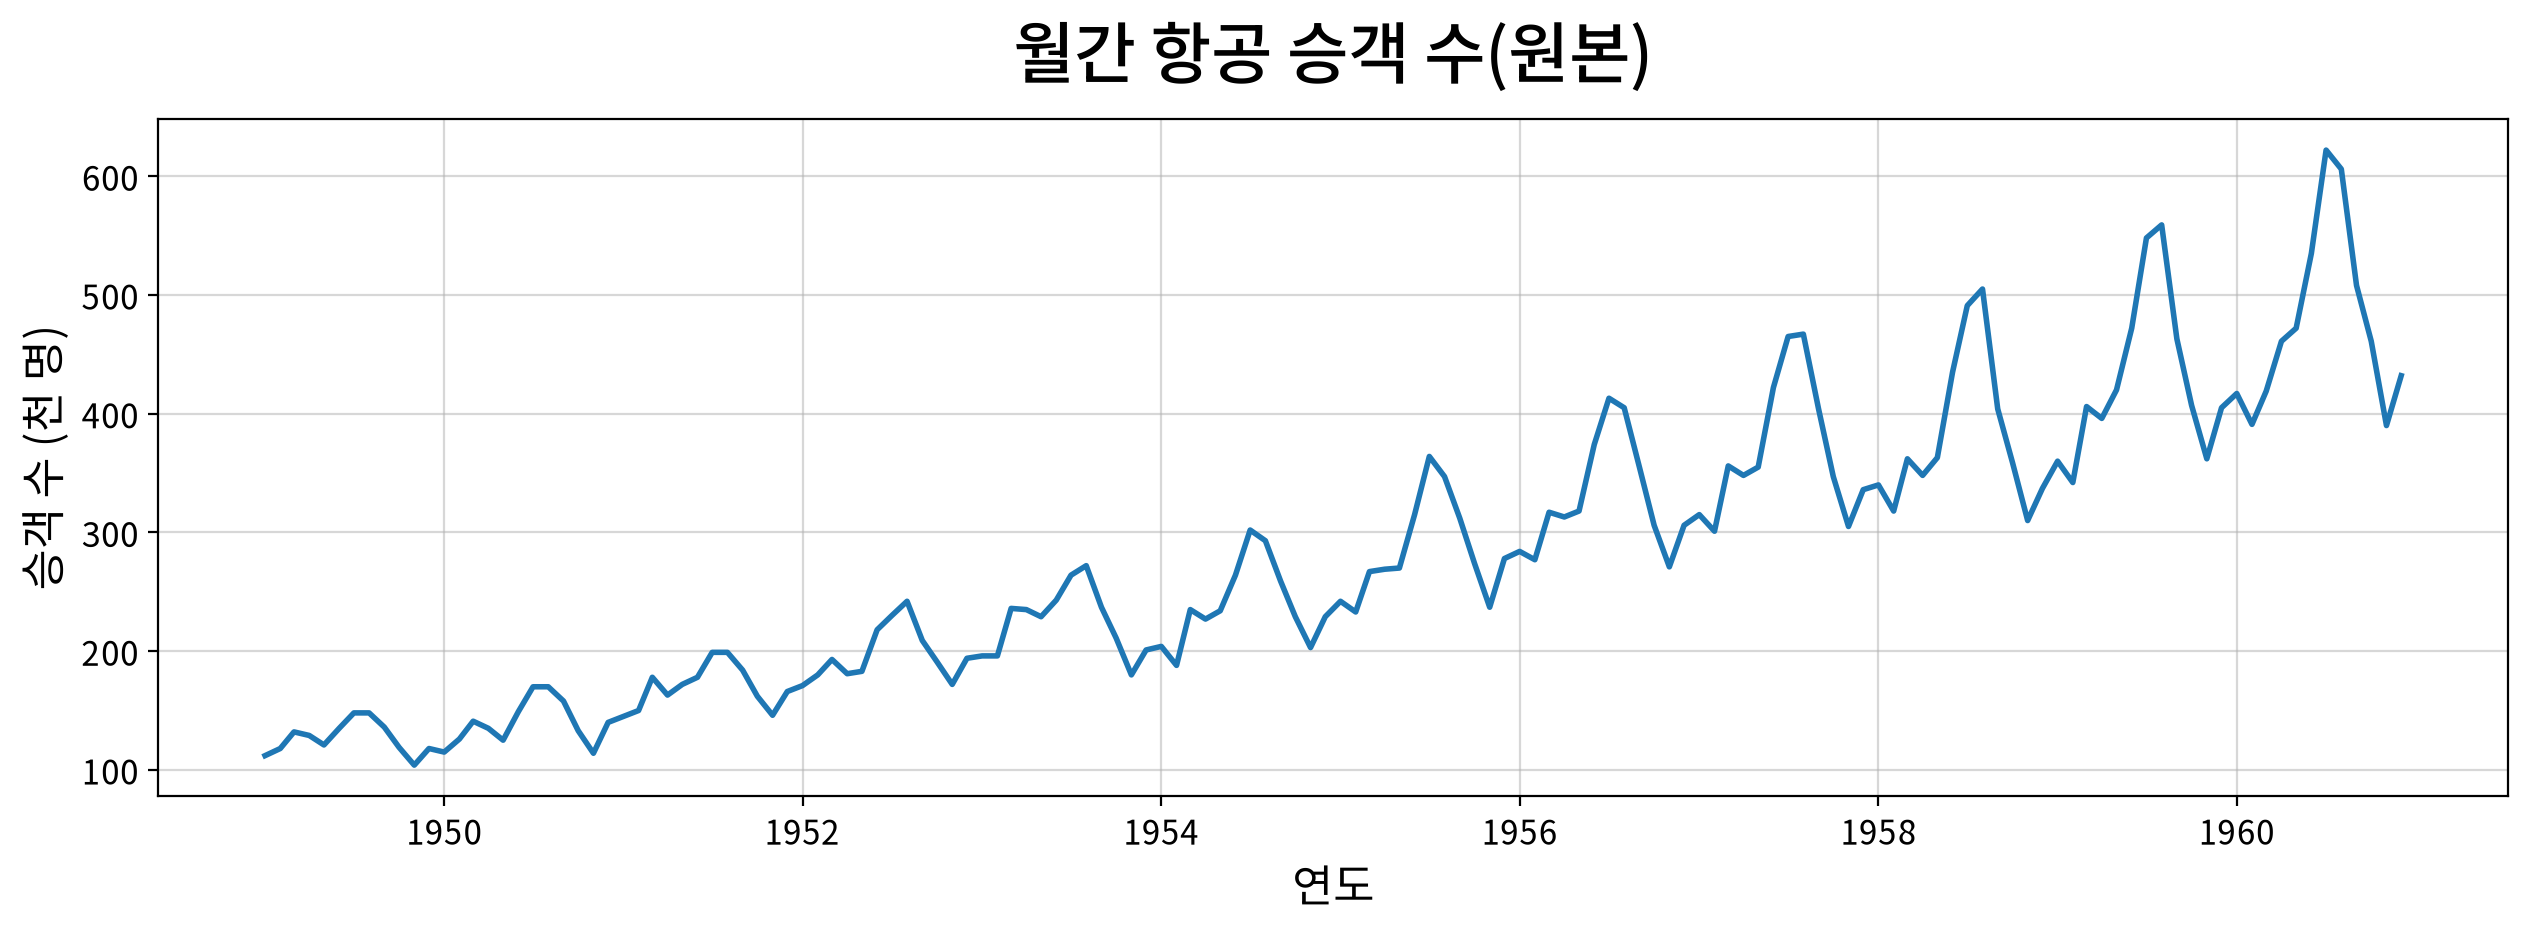

In [4]:
my_plot.lineplot(data=df1, x=df1.index, y="Passengers", 
                 title="월간 항공 승객 수(원본)", 
                 xlabel="연도", ylabel="승객 수 (천 명)", 
                 width=1280, height=480)


결과 확인 

추세: 우상향

계절성: 1년으로 추정 

변동폭: 변동폭이 수준(level)에 비례해 커진다\
승객이 100명일때와 500명일때의 성수기 증가분은 절대량이 다르다\
이 데이터는 추세+계절성+변동폭 증가 세가지 문제를 한꺼번에 갖고 있고, 각각 다른 방법으로 해결해야 한다


## # 정상성 Stationarity 의 이해 

### 시간이 흘러도 통계적 성질이 변하지 않는 상태 
시간축의 어느 구간을 잘라내도 비슷하게 생긴 상태 

비정상성 시계열 : 시간에 따라 평균이나 분산이 변하는 자료. 현실에서 수집되는 대부분의 자료
정상성 시계열 : 비정상 시계열을 전처리하여 다루기 쉽게 변환한 자료 

시계열 분석의 시작점은 "우리 데이터가 정상인가"가 아니라, "어떻게 정상으로 만들 것인가?"이다.

### 정상성의 필요성 
시계열 분석의 논리 -> 과거에 성립하던 규칙이 미래에도 성립한다 \
    평균이 계속 올라가는 데이터는 과거의 평균과 미래의 평균이 다르다.\
    규칙이 시점마다 달라지므로, 과거에서 배운 것을 미래에 그대로 적용할 수 없다. 

정상시계열: 과거에 배운 규칙을 미래에 적용 가능 \ 
비정상시계열: 과거의 규칙과 미래의 규칙이 다르다 -> 학습한 규칙이 무의미 

### 정상성의 조건 
평균이 일정

분산이 일정 

공분산이 시차에만 의존 

세조건 중 1,2의 처방이 서로 다르다 \
추세문제에 로그변환을 쓰거나, 분산 문제에 차분을 쓰는 것은 잘못된 처방이다. 

### 강정상성 / 약정상성 

강정상성 Strict 시계열의 모든 분포가 시간 이동에 대해 불변 / 검증이 사실상 불가능 

약정상성 Weak  평균 일정+ 분산 일정 + 공분산이 시차에만 의존 / 실무에서 "정상성"이라 하면 이것 

이 강의를 포함해 일반적으로 정상성=약정상성을 의미한다. 

## #03. 정상성 확인

### 1. 구간을 나눠서 확인하기 
정상성의 정의가 "어느 구간을 잘라도 비슷하였다"이므로, 실제로 잘라서 비교한다 

    3년간의 데이터이므로 3개 구간으로 나눈다 
    전체의 데이터 길이에 대해 나누어 떨어지기만 하면 어느 숫자이건 상관없음 

In [5]:
size = len(df1)// 3 # 데이터를 3개 구간으로 나눔
parts = [] 

for i in range(3): #구간 수 만큼 반복
    # 구간의 시작 위치 (0*12, 1*12, 2*12) ~ 끝 위치(1*12, 2*12, 3*12)사이를 자름 
    part = df1['Passengers'].iloc[i * size : (i +1)*size]   

    # 구간 내 평균과 표준편차를 계산하여 리스트에 추가 
    parts.append({
        "구간": f"구간 {i+1}", 
        "시작": part.index[0].strftime("%Y-%m"),
        "종료": part.index[-1].strftime("%Y-%m"),
        "평균": round(part.mean(), 2), 
        "표준편차": round(part.std(), 2),
    })  

DataFrame(parts)

,구간,시작,종료,평균,표준편차
0,구간 1,1949-01,1952-12,158.380,33.090
1,구간 2,1953-01,1956-12,269.040,55.730
2,구간 3,1957-01,1960-12,413.480,78.500


결과확인 

평균 

커짐 
-> 조건1 위배. 추세가 존재함.

표준편차 

-> 조건2 위배. 변동폭 증가 

### 2. 이동평균과 이동표준편차 
3개 구간으로 나누는 대신 1년(12개월)짜리 창을 옆으로 밀면서 평균과 표준편차를 계산하면 변화의 모습을 연속적으로 볼 수 있다. 
3개 구간을 나누는 것과 같은 효과 



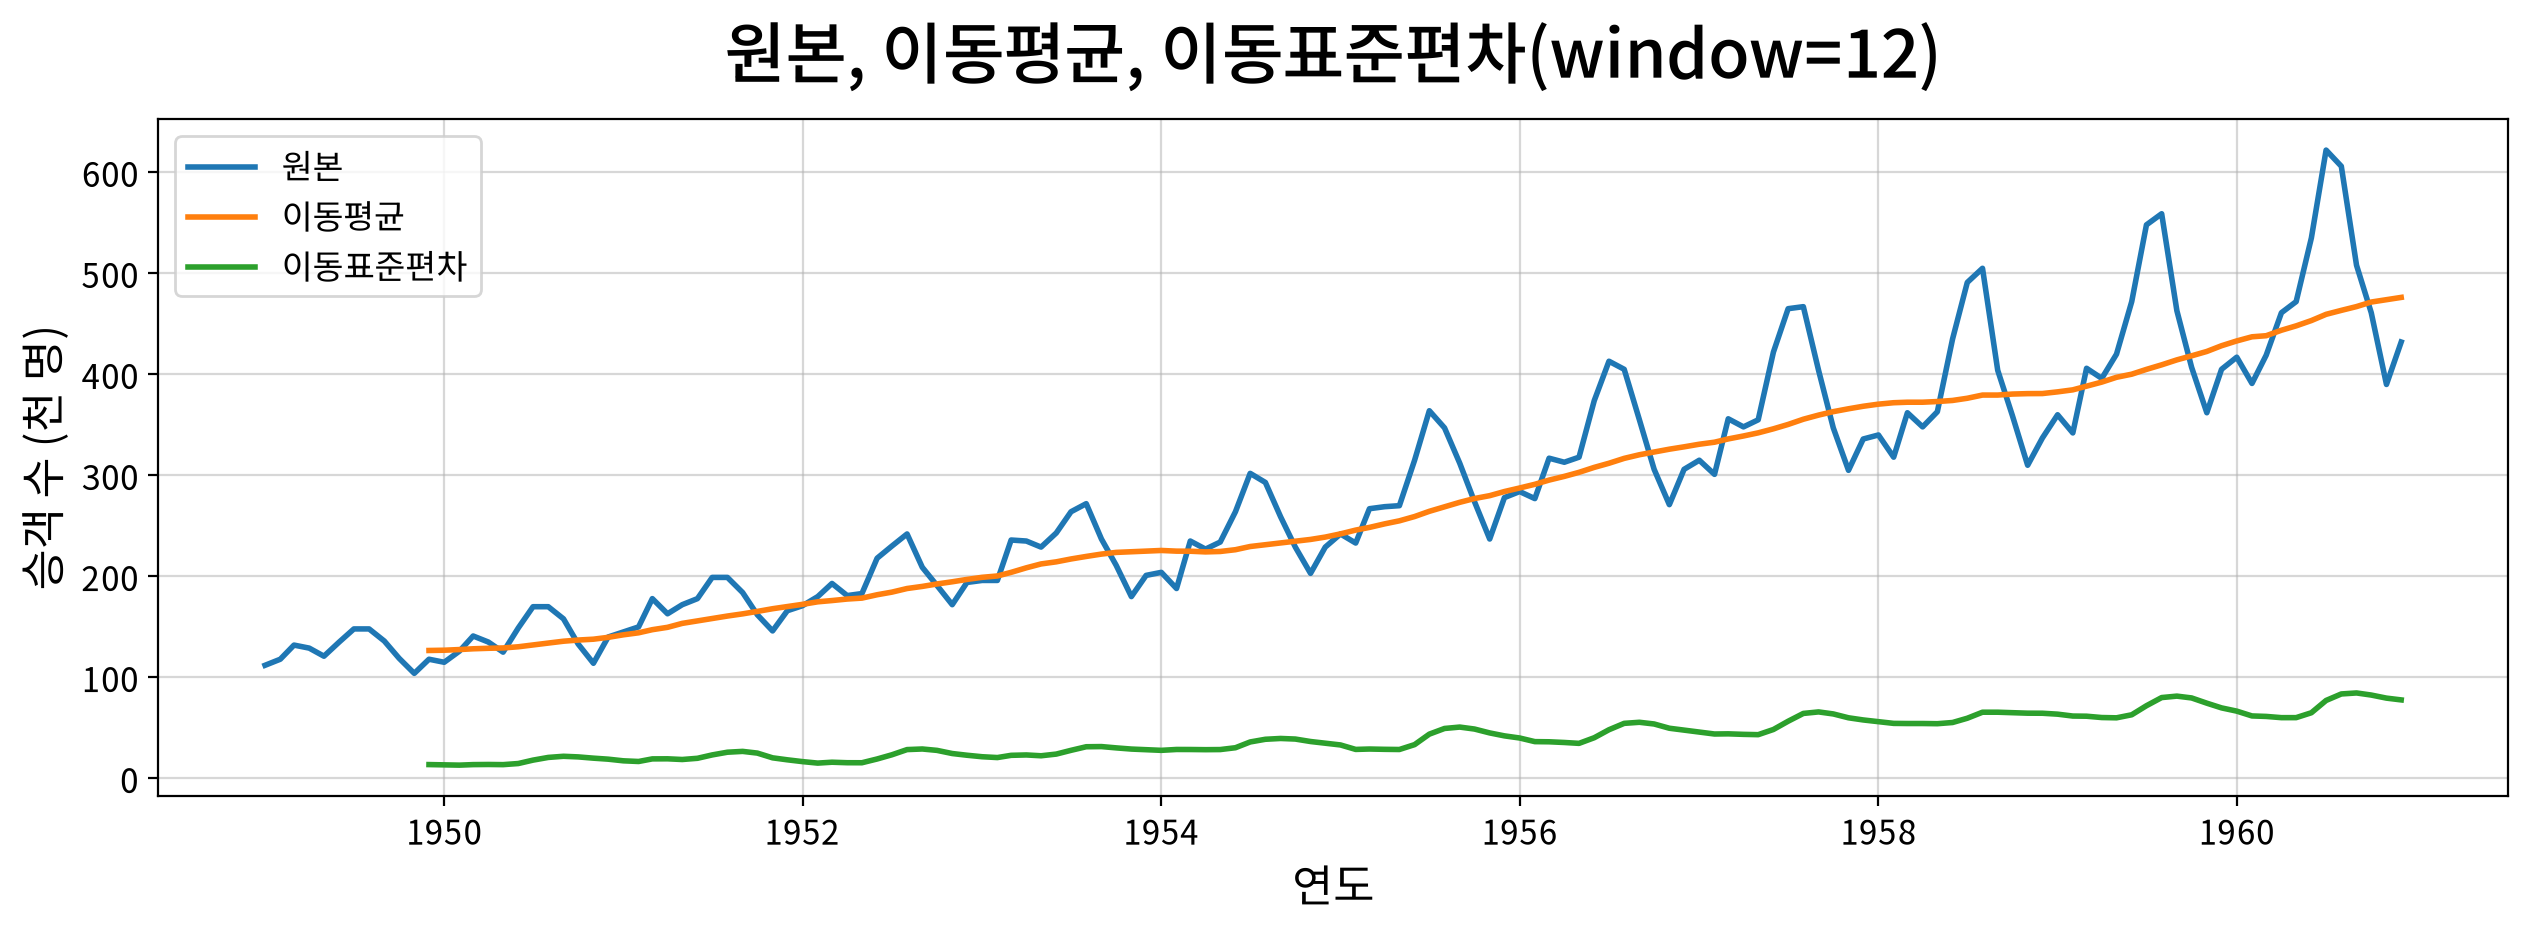

In [6]:
window = 12 # 월간 데이터이므로 1년=12개월

roll_mean = df1['Passengers'].rolling(window).mean()
roll_std = df1['Passengers'].rolling(window).std()

fig, ax = my_plot.init(width=1280, height=480,
                       title=f"원본, 이동평균, 이동표준편차(window={window})",
                       xlabel="연도", ylabel="승객 수 (천 명)")

my_plot.lineplot(x=df1.index, y=df1['Passengers'], label="원본", ax=ax)
my_plot.lineplot(x=roll_mean.index, y=roll_mean, label="이동평균", ax=ax)
my_plot.lineplot(x=roll_std.index, y=roll_std, label="이동표준편차", ax=ax)

ax.legend()
my_plot.show()

꼭 필요한 파라미터 외에 기타 등등 이라는 의미의 **params 파라미터 추가함 

### 이동평균과 이동표준편차 결과 확인

평균 우상향 -> 평균이 일정하지 않다\
표준편차 우상향 -> 분산이 일정하지 않다 

정상 시계열이라면 두 선 모두 수평선에 가까워야 한다 

이 그래프는 전처리를 할 때마다 다시 그려서 얼마나 수평에 가까워 졌는지 확인하는데 쓴다.

## # 단위근 Unit Root의 이해 

### ADF Augmented Dickey Fuller 검정에 사용되는 기본 개념 

파이가 0인 상태를 단위근이 존재한다고 말하며, 이때 식은 다음과 같이 변형된다.

## #04. ADF 검정 

### 1. 정상/비정상 샘플 만들기 

백색잡음 White Noise 매번 독립적인 난수 파이=0 정상 \
랜덤워크 Random Walk 백색잡음의 누적합 파이=1 비정상 

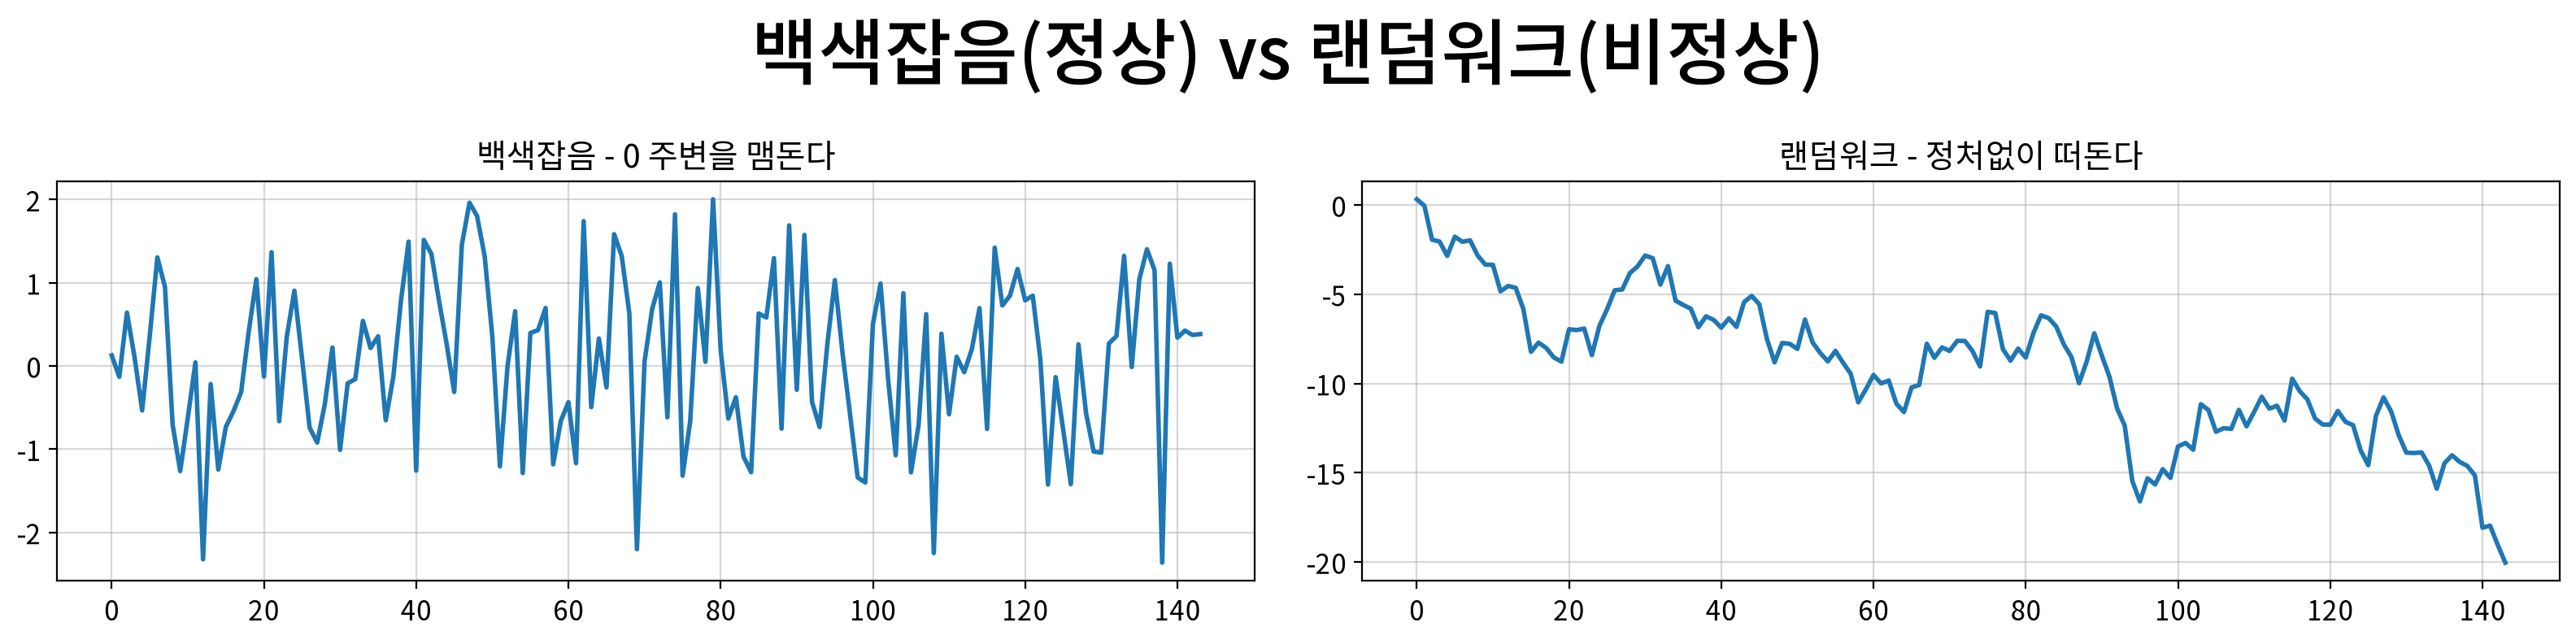

In [7]:
rng = np.random.default_rng(0) # 결과 재현을 위해 시드 고정 

white_noise = rng.normal(0, 1, 144) # 백색잡음
random_walk = np.cumsum(rng.normal(0, 1, 144))  # 랜덤워크 = 백색잡음의 누적합 

fig, ax = my_plot.init(rows=1, cols=2, width=800, height=400, 
                       title="백색잡음(정상) vs 랜덤워크(비정상)")  

my_plot.lineplot(x=range(144), y=white_noise, ax=ax[0]) 
ax[0].set_title("백색잡음 - 0 주변을 맴돈다")   

my_plot.lineplot(x=range(144), y=random_walk, ax=ax[1])
ax[1].set_title("랜덤워크 - 정처없이 떠돈다")

my_plot.show()

결과확인 

백색잡음 

아무리 멀리 벗어나도 0으로 되돌아온다 

랜덤워크 

한번 움직이면 그 자리에서 다시 출발해 되돌아올 이유가 없다 

-> 비정상 데이터 단위근이 존재함을 발견함. 

### 2. 정상성 검정 - 결과를 표로 만드는 함수 정의
adfuller()는 결과를 튜플로 돌려준다 \
몇번째에 무엇이 있는지 매번 외울 수 없으므로, \
필요한 값만 뽑아 딕셔너리로 돌려주는 함수를 하나 만들어두고 이 단원 내내 재사용 한다.

In [8]:
def adf_test(data, name):
    x = Series(data).dropna() # 결측치 제거 
    stat, pvalue, lag, _, crit, _ = adfuller(x) # ADF 검정 수행 

    return {
        "대상": name, 
        "관측치 수": len(x), 
        "검정통계량(ADF)": round(stat, 3), #검정통계량
        "p-value": round(pvalue, 3), # p-value
        "사용 시차": lag, # 사용된 시차 수 
        "1% 기각값": round(crit["1%"], 3), 
        "5% 기각값": round(crit["5%"], 3), 
        "10% 기각값": round(crit["10%"], 3),
        "판정": "정상" if pvalue < 0.05 else "비정상", 
    }

### 3. 샘플 데이터에 대한 정상성 검정 

In [9]:
check = [
    adf_test(white_noise, "백색잡음 (정상일 것)"), 
    adf_test(random_walk, "랜덤워크 (비정상일 것)"), 

    # 차분 1회 수행 --> 단순히 numpy.diff()를 사용하기만 하면 된다 
    adf_test(np.diff(random_walk), "랜덤워크의 1차 차분")   
]

DataFrame(check)[["대상", "검정통계량(ADF)", "p-value", "5% 기각값", "판정"]]

,대상,검정통계량(ADF),p-value,5% 기각값,판정
0,백색잡음 (정상일 것),-11.105,0.000,-2.882,정상
1,랜덤워크 (비정상일 것),-1.337,0.612,-2.882,비정상
2,랜덤워크의 1차 차분,-11.834,0.000,-2.882,정상


### 4. 실습 데이터에 대한 정상성 판정 

In [10]:
r_origin = adf_test(df1["Passengers"], "원본")  

Series(r_origin)    

대상               원본
관측치 수           144
검정통계량(ADF)    0.815
p-value       0.992
사용 시차            13
1% 기각값       -3.482
5% 기각값       -2.884
10% 기각값      -2.579
판정              비정상
dtype: object

H0 귀무가설 : 단위근이 존재한다 -> 비정상이다 \
H1 대립가설 : 단위근이 없다 -> 정상이다 

ADF는 귀무가설이 "비정상"이다

정규성 검정과 방향이 반대이므로 p가 작아야 정상이다 

## #05. 비정상 데이터 처방 

### 변환과 차분의 차이 

변환 Transformation 분산이 일정하지 않음 -> 로그변환 \
차분 Difference 평균이 일정하지 않음 -> numpy의 diff() 함수 사용 

변환은 분산문제(조건2)만 푼다. \
변동폭이 수준에 비례해 커질때 로그가 정확히 들어맞는다 

### 1. 변환 Transform 

In [11]:
log_s = np.log(df1['Passengers']) #로그변환 

# 연도별 표준편차 계산 
std_origin = df1['Passengers'].groupby(df1.index.year).std()
std_log = log_s.groupby(df1.index.year).std()

compare_std = DataFrame({
    "원본 표준편차": std_origin.round(2), 
    "로그 표준편차": std_log.round(4),
})

compare_std.index.name = "연도"

display(compare_std)

print(f"원본 - 최대/최소 비율: {std_origin.max() / std_origin.min():.2f}배")
print(f"로그 - 최대/최소 비율: {std_log.max() / std_log.min():.2f}배")


,원본 표준편차,로그 표준편차
연도,,
1949,13.720,0.108
1950,19.070,0.135
1951,18.440,0.108
1952,22.970,0.113
1953,28.470,0.128
1954,34.920,0.144
1955,42.140,0.144
1956,47.860,0.141
1957,57.890,0.152


원본 - 최대/최소 비율: 5.67배
로그 - 최대/최소 비율: 1.48배


결과 확인 

완벽히 같아지진 않았지만 "분산이 일정하다"고 볼 수 있는 수준

### 2. 로그변환 결과 확인 

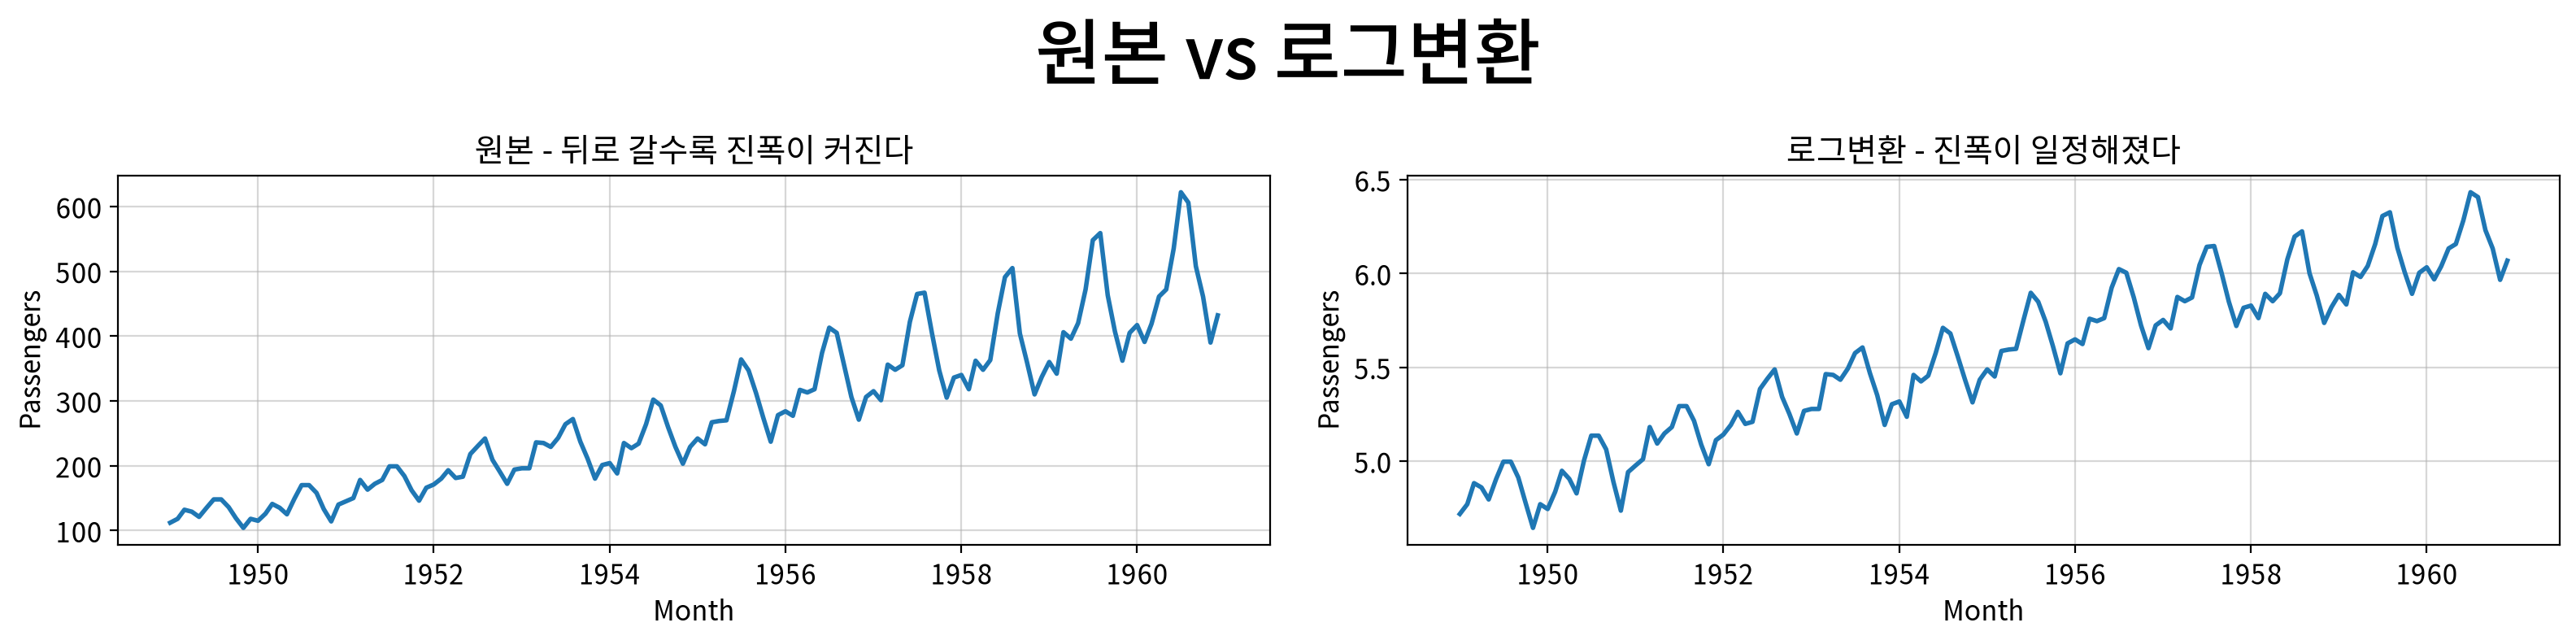

{'대상': '로그변환',
 '관측치 수': 144,
 '검정통계량(ADF)': np.float64(-1.717),
 'p-value': np.float64(0.422),
 '사용 시차': 13,
 '1% 기각값': np.float64(-3.482),
 '5% 기각값': np.float64(-2.884),
 '10% 기각값': np.float64(-2.579),
 '판정': '비정상'}

In [12]:
fig, ax = my_plot.init(rows=1, cols=2, width=800, height=400, 
                       title="원본 vs 로그변환")

my_plot.lineplot(x=df1.index, y=df1['Passengers'], ax=ax[0])    
ax[0].set_title("원본 - 뒤로 갈수록 진폭이 커진다")

my_plot.lineplot(x=log_s.index, y=log_s, ax=ax[1])
ax[1].set_title("로그변환 - 진폭이 일정해졌다")

my_plot.show()

# 로그 변환에 대한 ADF 검정 결과 
r_log = adf_test(log_s, "로그변환")
r_log

결과확인 

봉우리 높이가 처음부터 끝까지 거의 같아졌다 -> 조건2 해결 \
그러나 여전히 우상향 한다 -> 조건1은 그대로임.

크게 좋아졌으나, 기각값에 못미침. \
-> 로그변환은 분산만 잡음. 추세는 해결 못함.\
-> 추세를 없애려면 차분이 필요함. 

## # 차분 Differencing의 이해 

각 관측값과 바로 이전 관측값의 차이 

얼마인가(수준)를 얼마나 변했는가(변화량)로 바꾸는 것. \ 

예: 1949년 2월 승객 118명, 1월 112명 -> 1차 차분값 = +- 6


이번달 승객은 432명이다 -> 이번달 승객은 지난달보다 -30명 줄었다. \
계속 커지므로 평균이 일정하지 않다 -> 증감은 0 주변을 맴돈다 -> 평균이 일정해진다.

차분을 하면 해석의 단위가 바뀐다. \
예측한 값은 "승객 수"가 아니라 "승객 수의 변화량"이다 \
첫번째 값은 이전 값이 없어 결측치가 발생한다. 

### 3. 차분 수행 

In [13]:
# 차분 수행 -> 차분의 결과로 발생하는 결측치는 제거한다. 
df2 = df1.diff().dropna()

print(f"원본 {len(df1)}개 -> 1차 차분 {len(df2)}개 (첫 행 손실)")
df2.head()

원본 144개 -> 1차 차분 143개 (첫 행 손실)


,Passengers
Month,
1949-02-01,6.000
1949-03-01,14.000
1949-04-01,-3.000
1949-05-01,-8.000
1949-06-01,14.000


### 4. 차분 결과 시각화 및 ADF 검정 


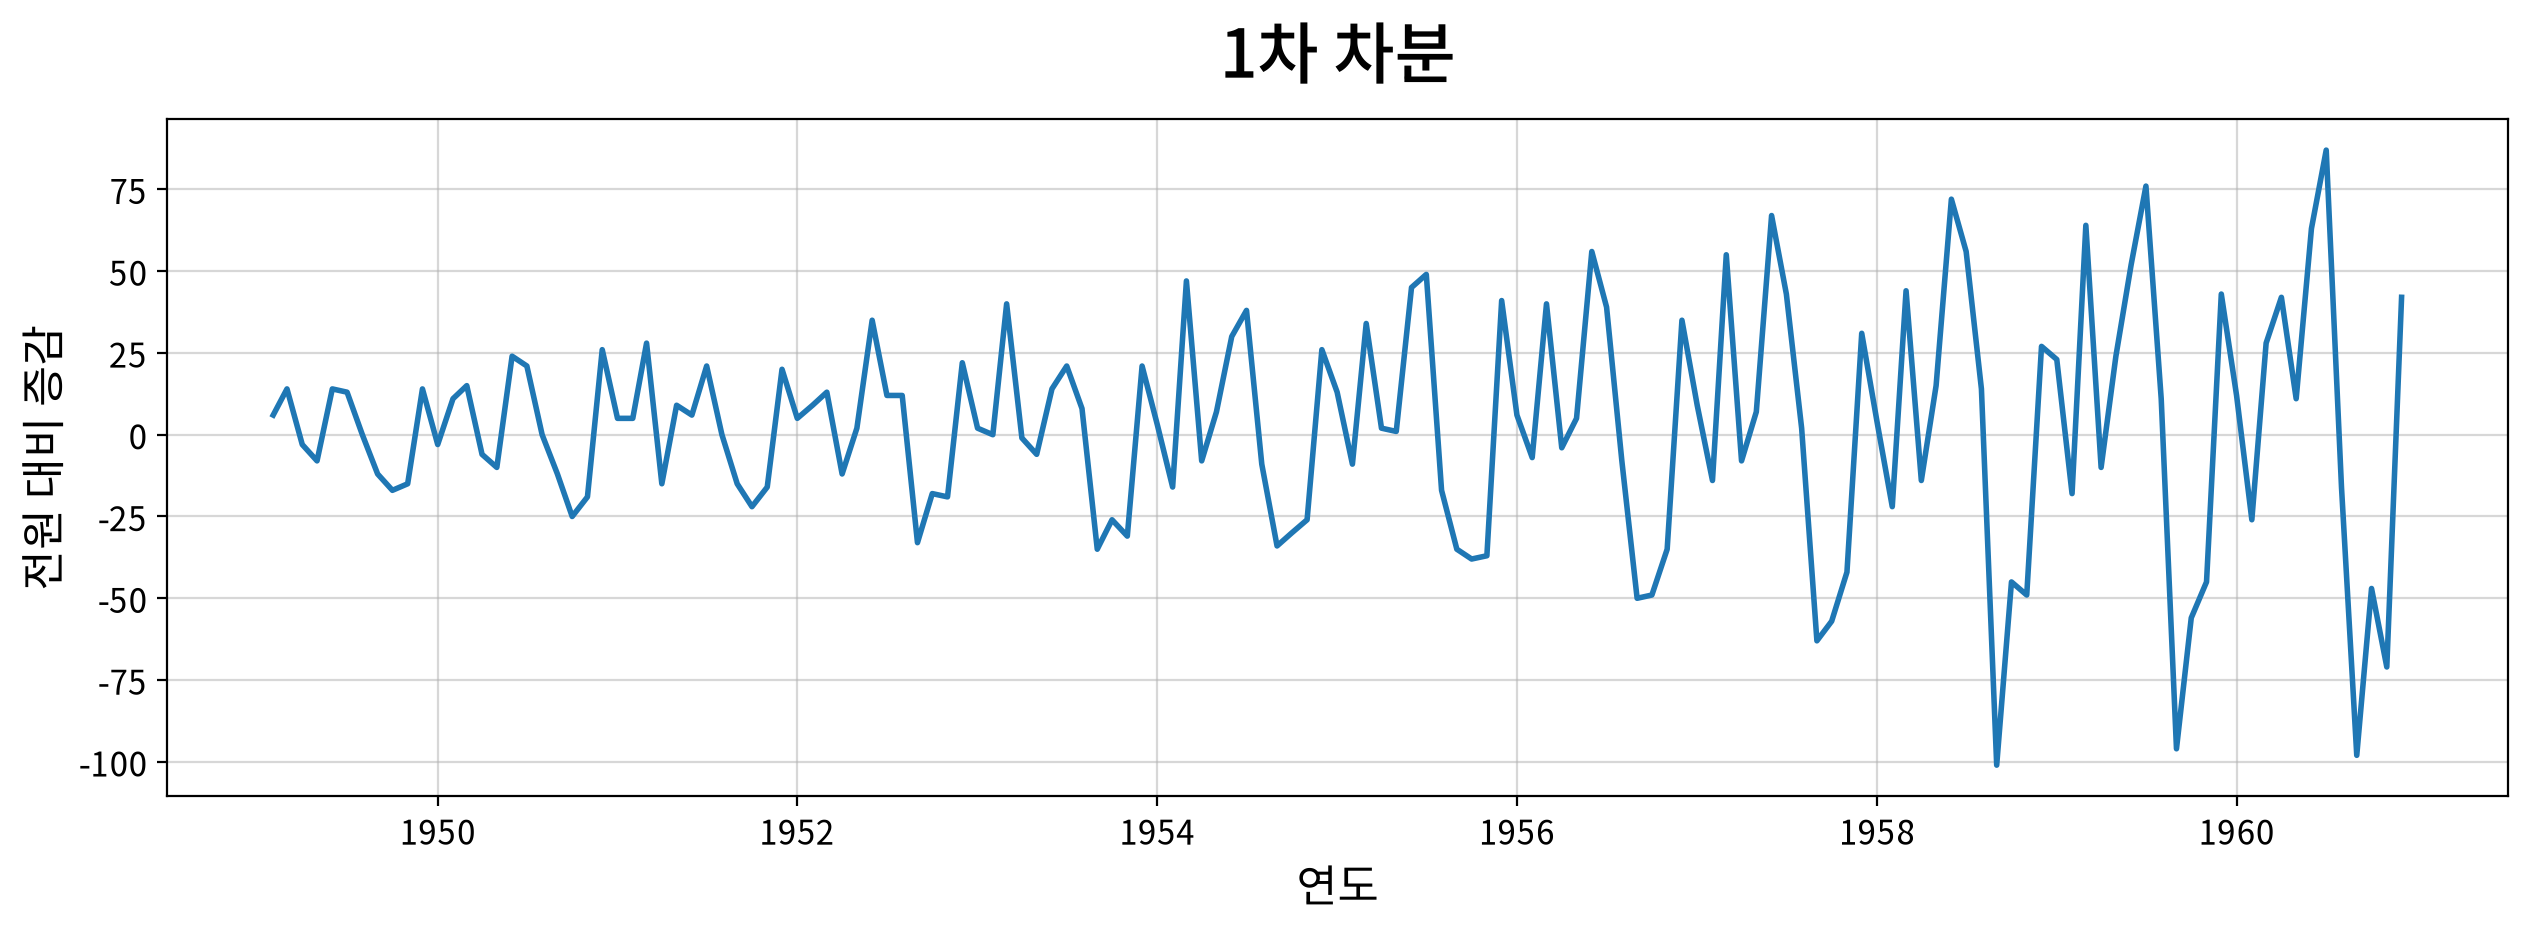

대상            1차 차분
관측치 수           143
검정통계량(ADF)   -2.829
p-value       0.054
사용 시차            12
1% 기각값       -3.482
5% 기각값       -2.884
10% 기각값      -2.579
판정              비정상
dtype: object

In [14]:
my_plot.lineplot(data=df2, x=df2.index, y="Passengers", 
                 title = "1차 차분", 
                 xlabel="연도", ylabel="전원 대비 증감", 
                 width=1280, height=480)

r_d1 = adf_test(df2["Passengers"], "1차 차분")

Series(r_d1)

결과 확인 

그래프가 0을 중심으로 위아래로 움직인다 \
우상향 추세가 사라졌다. -> 조건1 해결

뒤로 갈수록 진폭이 커진다.\
분산 문제는 그대로 남아있다. -> 조건2 미해결 

p-value = 0.0542 \
0.05를 아슬아슬하게 넘는다. 

## # 판정이 애매할 때는 어떻게 하는가 

정상성이 확보될 때까지 로그변환 혹은 차분을 선택적으로 반복해야 한다. 

1) 기각값과 비교한다 

2) 그래프에서 무엇이 남았는지 확인한다 \
    ex. 평균은 잡혔지만 진폭이 커지고 있다. 남은 문제는 추세가 아니라 분산이다. 

3) 남은 문제에 맞는 처방을 쓴다 

    분산이 일정하지 않음 -> 로그변환 vs 잘못된처방: [차분 한번 더 --> 오히려 분산이 커진다.]


    계절성이 남아있음 -> 계절차분 vs 잘못된 처방: [차분 한번 더]  

    [경고] "p-value가 0.05를 넘으니 차분을 한번 더 한다." 가 가장 흔하고 나쁜 선택이다. 

### 5. 2차 차분 실험 
차분을 한번 더 해보고, 차수별로 표준화가 어떻게 변하는지 관찰한다. 

In [15]:
over_diff = [] #차분 횟수별 ADF 검정 결과를 담을 리스트 
tmp = df1["Passengers"].copy() # 원본 데이터를 복사하여 차분 수행 

for i in range(4): #0차 ~ 3차 차분까지 반복
    r = adf_test(tmp,f"{i}차 차분" if i >0 else "원본") # ADF 검정 수행 
    r["표준편차"] = round(tmp.std(),2) #표준편차 계산 
    over_diff.append(r) #결과를 리스트에 추가 
    tmp = tmp.diff().dropna() # 다음 차분을 위해 1차 차분 수행 후 결측치 제거 

DataFrame(over_diff)[["대상", "관측치 수", "검정통계량(ADF)", "p-value","판정", "표준편차"]]

,대상,관측치 수,검정통계량(ADF),p-value,판정,표준편차
0,원본,144,0.815,0.992,비정상,119.970
1,1차 차분,143,-2.829,0.054,비정상,33.750
2,2차 차분,142,-16.384,0.000,정상,39.860
3,3차 차분,141,-9.435,0.000,정상,60.980


## # 과대차분 Over-differencing 
직전 실험에서 발견된 현상을 과대차분이라고 한다 

p-value 하락으로 좋아보이지만, 표준편차가 커짐 -> 데이터에 없던 노이즈를 만들어냈다는 뜻. 

과대차분 판별 규칙 - 표준편차가 최소가 되는 차수를 넘기지 않는다. \
과대차분된 데이터로 ARIMA(예측모델)을 만들면 계수 추정이 불안정해지고 예측 구간이 쓸데없이 넓어진다. \
p-value를 낮추는 것이 목적이 아니라, 필요한 만큼만 차분하는 것이 목적이다.

그렇다면 1차 차분 p=0.0542의 남은 문제는?\
차분 횟수를 늘리는 대신 남아있는 계절성과 분산을 직접 처리

## # 계절차분 Seasonal Differencing 
일반차분 -> 직전 값과의 비교 / 계절 차분 -> 작년 같은 달과의 비교 

s는 계절 주기 \
월간 12, 분기 4, 일간 데이터의 요일 주기 7 \
우리 데이터는 매년 여름에 봉우리가 생기므로 s =12

앞의 12개 행이 결측치가 된다. \
144개 -> 132개 


계절차분은 
𝑌
𝑡
−
𝑌
𝑡
−
12
Y
t
	​

−Y
t−12
	​

 (작년 같은 달과 비교)라서, 앞의 12개는 비교할 "작년 값"이 아예 없으니까 결측치가 되는 거

 그래서 144 - 12 = 132가 되는 거고, 이건 그냥 산수라기보다 "s=12만큼 뒤로 밀어서 뺄셈했으니 앞쪽 s개는 계산 불가"라는 구조적인 이유 때문이야. 일반차분에서 1개 사라지는 거랑 똑같은 원리인데, 계절차분은 한 칸이 아니라 s칸을 밀기 때문에 s개가 사라지는 거지.

### 6. 계절 차분 Seasonal Differencing 
pandas에서는 diff(12)로 간단히 수행한다. 앞의 12개 행이 결측치가 된다. 

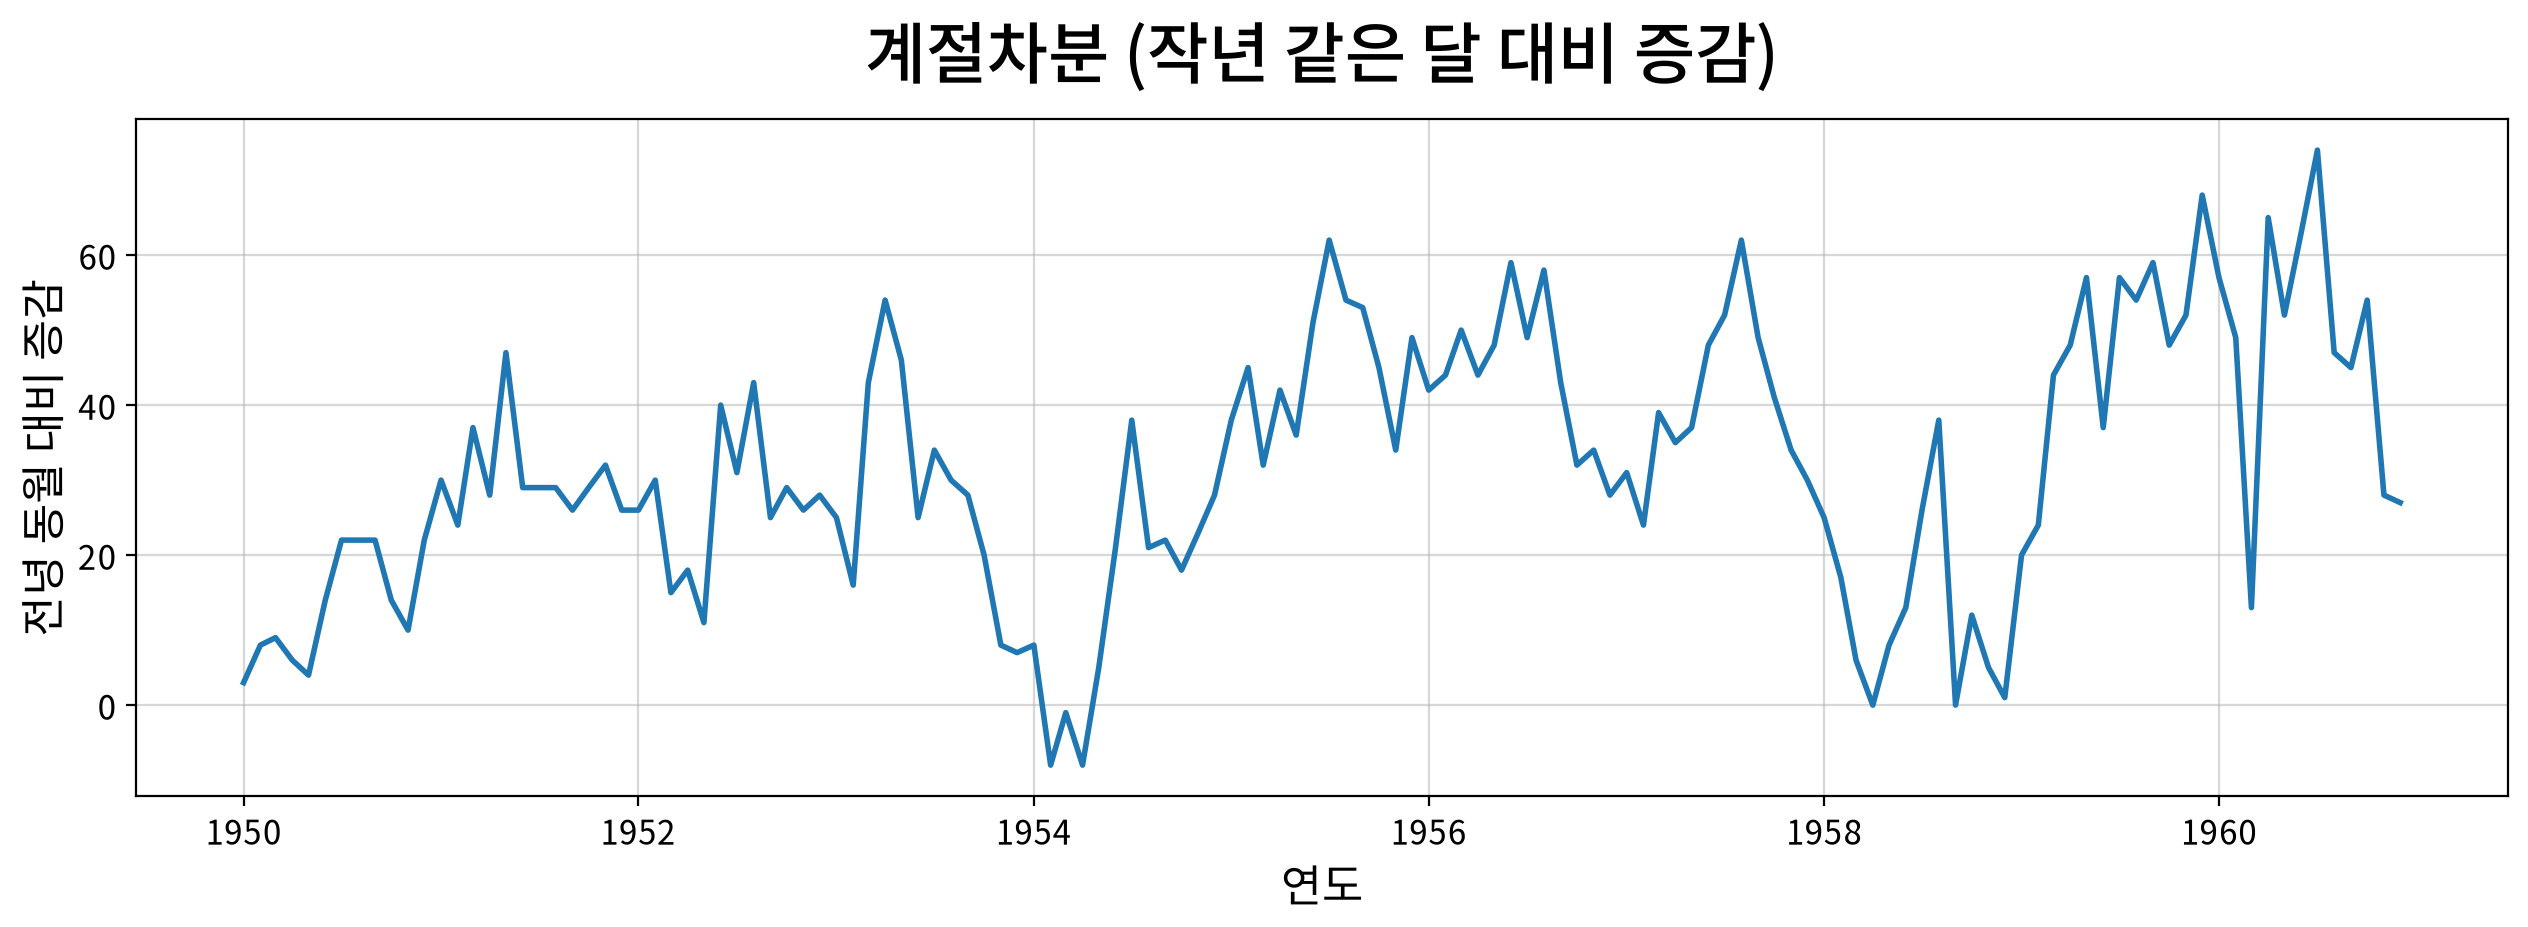

대상            계절차분(12)
관측치 수              132
검정통계량(ADF)      -3.383
p-value          0.012
사용 시차                1
1% 기각값          -3.482
5% 기각값          -2.884
10% 기각값         -2.579
판정                  정상
dtype: object

In [16]:
df3 = df1["Passengers"].diff(12).dropna()

my_plot.lineplot(x=df3.index, y=df3, title="계절차분 (작년 같은 달 대비 증감)", 
                 xlabel="연도", ylabel="전녕 동월 대비 증감", 
                 width=1280, height=480)

r_ds = adf_test(df3, "계절차분(12)") #ADF 검정 수행 
Series(r_ds)

## #06. 전처리 조합 비교 - 무엇을 쓸 것인가? 

지금까지 배운 세가지 도구(로그변환/ 일반차분/ 계절차분)를 조합해 한꺼번에 비교한다. \
    조합을 딕셔너리 하나로 정의해두고 반복문으로 검정만 돌리면 된다.\
    diff()가 일반차분, diff(12)가 계절차분이므로 메서드를 이어 붙이면 그대로 조합이 된다. 

### 1. 전처리 파이프라인 

In [17]:
s = df1["Passengers"]
ls = np.log(s)

combos = {
    "1. 원본":s,
    "2. 1차 차분": s.diff(), 
    "3. 2차 차분": s.diff().diff(),
    "4. 로그변환": ls, 
    "5. 로그 + 1차 차분": ls.diff(), 
    "6. 계절차분(12)": s.diff(12),
    "7. 로그 + 계절 차분(12)":ls.diff(12), 
    "8. 로그+ 1차 차분 + 계절차분(12)": ls.diff().diff(12),
}

### 2. 조합 비교 

In [18]:
report = [] # ADF 검정 결과를 담을 리스트 

for name , x in combos.items() : # combos 딕셔너리의 Key, value를 순회 
    r = adf_test(x, name) #ADF 검정 수행 
    r["표준편차"] = round(x.dropna().std(),3) #표준편차 계산 
    report.append(r) #결과를 리스트에 추가 

# ADF 검정 결과를 데이터 프레임으로 변환하여 출력 
DataFrame(report)[["대상", "관측치 수","검정통계량(ADF)", "p-value", "5% 기각값", "표준편차", "판정"]]

,대상,관측치 수,검정통계량(ADF),p-value,5% 기각값,표준편차,판정
0,1. 원본,144,0.815,0.992,-2.884,119.966,비정상
1,2. 1차 차분,143,-2.829,0.054,-2.884,33.754,비정상
2,3. 2차 차분,142,-16.384,0.000,-2.884,39.856,정상
3,4. 로그변환,144,-1.717,0.422,-2.884,0.441,비정상
4,5. 로그 + 1차 차분,143,-2.717,0.071,-2.884,0.107,비정상
5,6. 계절차분(12),132,-3.383,0.012,-2.884,17.655,정상
6,7. 로그 + 계절 차분(12),132,-2.710,0.072,-2.886,0.062,비정상
7,8. 로그+ 1차 차분 + 계절차분(12),131,-4.443,0.000,-2.886,0.046,정상


3번. 정상이지만 직전 차분대비 분산 증가로 불채택

6번. 정상이지만 7번 대비 분산이 크고, p-value도 크다 

8번. 채택. 

## □ 시계열 데이터의 핵심 개념

| 비정상 데이터 처방은 문제별로 다르다 | 분산 → 변환, 추세 → 차분, 계절성 → 계절차분 |
|---|---|
| **ADF는 p가 작아야 정상** | 귀무가설이 "비정상"이다. 정규성 검정과 방향이 반대 |
| **과대차분을 피하라** | 표준편차가 최소가 되는 차수를 넘기지 않는다 |
| **p-value는 목표가 아니다** | 0에 가깝게 만드는 것이 아니라 필요한 만큼만 처리하는 것이 목표 |

### 이 데이터의 최종 결론

| 변환 | 로그변환 | 모델 외부 처리 |
|---|---|---|
| **일반차분 횟수** | 1회 | d = 1 |
| **계절차분 횟수** | 1회 | D = 1 |
| **계절 주기** | 12개월 | s = 12 |

> **시계열 분석 모델(ARIMA)에 지정해야 하는 파라미터**

---

### → 항공모형 (Airline Model)

로그변환 + 1차 차분 + 계절차분(12) 조합으로  
이 항공 승객 데이터를 분석하며 제안한 방식.  
지금도 시계열 분석의 교과서로 여겨진다.

*(Box & Jenkins, 1976)*

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, Series
import numpy as np

# 데이터 정상성 확인을 위한 ADF 검정
from statsmodels.tsa.stattools import adfuller

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 1. 데이터 로딩 후 시계열 인덱스 설정 

In [2]:
origin = load_data('air_passengers')

# 날짜 컬럼명만 알려주면 된다 
df = my_ts.set_index(origin, "Month")

print("인덱스 타입:", type(df.index))

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
인덱스 타입: <class 'pandas.DatetimeIndex'>


### 2. 구간별 비교 

In [3]:
# 구간을 3개로 나눠 비교 (#03-1과 같은 표)
my_ts.report_split(df, "Passengers", size=3)

,시작,종료,관측치 수,평균,표준편차,변동계수
구간,,,,,,
구간 1,1949-01-01,1952-12-01,48,158.375,33.086,0.209
구간 2,1953-01-01,1956-12-01,48,269.042,55.731,0.207
구간 3,1957-01-01,1960-12-01,48,413.479,78.498,0.190


### 3. 기간별 비교 

In [4]:
# 연도별로 묶어 변동폭 비교 (#05-1 과 같은 판단)
# freq = "YE" -> 연말 기준 1년씩 / "QE" -> 분기씩 / "ME" -> 월말 기준 한달 씩 
#        "WE" -> 주말 기준 1주일 씩 / "D" -> 하루씩 
my_ts.report_variation(df, "Passengers", freq="YE")

표준편차 최대/최소: 5.67배
변동계수 최대/최소: 1.56배
판정: 변동폭이 수준에 비례한다 -> 로그변환 권장 / 승법(multiplicative)모델


,평균,표준편차,변동계수
기간,,,
1949-12-31,126.667,13.720,0.108
1950-12-31,139.667,19.071,0.137
1951-12-31,170.167,18.438,0.108
1952-12-31,197.000,22.966,0.117
1953-12-31,225.000,28.467,0.127
1954-12-31,238.917,34.924,0.146
1955-12-31,284.000,42.140,0.148
1956-12-31,328.250,47.862,0.146
1957-12-31,368.417,57.891,0.157


### 4. ADF 검정 

In [5]:
my_ts.adf_test(df, "Passengers")

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
Passengers,144,0.815,0.992,13,-3.482,-2.884,-2.579,119.966,False,비정상


### 5. 시계열 데이터 변환 

In [6]:
# 로그변환 -> 1차 차분 -> 계절차분(12)을 한번에 적용한다 
log_diff = my_ts.transform(df, "Passengers", 
                           log=True, diff=1, seasonal_diff=1, period=12)    

# 변환 결과에 대한 ADF 검정 수행 
my_ts.adf_test(log_diff, name="로그 + 1차 차분 + 계절차분(12)")

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
로그 + 1차 차분 + 계절차분(12),131,-4.443,0.000,12,-3.487,-2.886,-2.580,0.046,True,정상


### 6. 최적 차분 회수 판정 

In [7]:
# 차수를 늘려가며 검정한다. 표준편차가 최소인 차수에 * 가 찍힌다. 
my_ts.adf_diff(df, "Passengers", max_diff=3)    

권장 차분 차수: 1차 차분 (표준편차가 최소인 지점)
1차 차분은 아직 비정상입니다. (p-value 0.0542). 차분을 더 늘리지 말고로그변환, 계절차분으로 남은 구조를 처리하세요 -> adf_transform()


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정,권장
원본,144,0.815,0.992,13,-3.482,-2.884,-2.579,119.966,False,비정상,
1차 차분,143,-2.829,0.054,12,-3.482,-2.884,-2.579,33.754,False,비정상,*여기까지
2차 차분,142,-16.384,0.000,11,-3.482,-2.884,-2.579,39.856,True,정상,과대차분
3차 차분,141,-9.435,0.000,14,-3.483,-2.885,-2.579,60.984,True,정상,과대차분


### 7. 자동 전처리 및 결과 검정 

In [8]:
# 로그 여부(2) x 일반차분 0~2회(3) x 계절차분 0~1회(2) = 12가지 조합을 자동 생성해 검정한다.
result = my_ts.adf_transform(df, "Passengers", period=12, max_diff=2)   
result

조합 12개 중 정상 7개
권장 전처리: 로그변환 + 1차 차분 + 계절차분(12)


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
로그변환 + 1차 차분 + 계절차분(12),131,-4.443,0.000,12,-3.487,-2.886,-2.580,0.046,True,정상
로그변환 + 2차 차분 + 계절차분(12),130,-4.305,0.000,10,-3.487,-2.886,-2.580,0.075,True,정상
로그변환 + 2차 차분,142,-8.197,0.000,13,-3.483,-2.884,-2.579,0.135,True,정상
1차 차분 + 계절차분(12),131,-15.596,0.000,0,-3.482,-2.884,-2.579,12.357,True,정상
계절차분(12),132,-3.383,0.012,1,-3.482,-2.884,-2.579,17.655,True,정상
2차 차분 + 계절차분(12),130,-8.098,0.000,7,-3.485,-2.886,-2.580,20.072,True,정상
2차 차분,142,-16.384,0.000,11,-3.482,-2.884,-2.579,39.856,True,정상
로그변환 + 계절차분(12),132,-2.710,0.072,12,-3.487,-2.886,-2.580,0.062,False,비정상
로그변환 + 1차 차분,143,-2.717,0.071,14,-3.483,-2.884,-2.579,0.107,False,비정상
로그변환,144,-1.717,0.422,13,-3.482,-2.884,-2.579,0.441,False,비정상


Month
1950-02-01    0.039
1950-03-01    0.000
1950-04-01   -0.020
1950-05-01   -0.013
1950-06-01    0.066
              ...  
1960-08-01   -0.046
1960-09-01    0.012
1960-10-01    0.032
1960-11-01   -0.050
1960-12-01   -0.010
Name: 로그변환 + 1차 차분 + 계절차분(12), Length: 131, dtype: float64

## # 연습문제 

In [9]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, Series
import numpy as np

# 데이터 정상성 확인을 위한 ADF 검정
from statsmodels.tsa.stattools import adfuller

In [10]:
origin = load_data('temperatures_seoul')    
origin.head()

print(f"데이터셋 크기: {origin.shape[0]}행 {origin.shape[1]}열")

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
데이터셋 크기: 602행 2열


In [11]:
df1 = origin.set_index("날짜")

print("인덱스 타입: ", type(df1.index))
print("기간: ", df1.index[0].strftime("%Y-%m"), "~", df1.index[-1].strftime("%Y-%m"))   
df1.head()

인덱스 타입:  <class 'pandas.DatetimeIndex'>
기간:  1973-07 ~ 2023-08


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


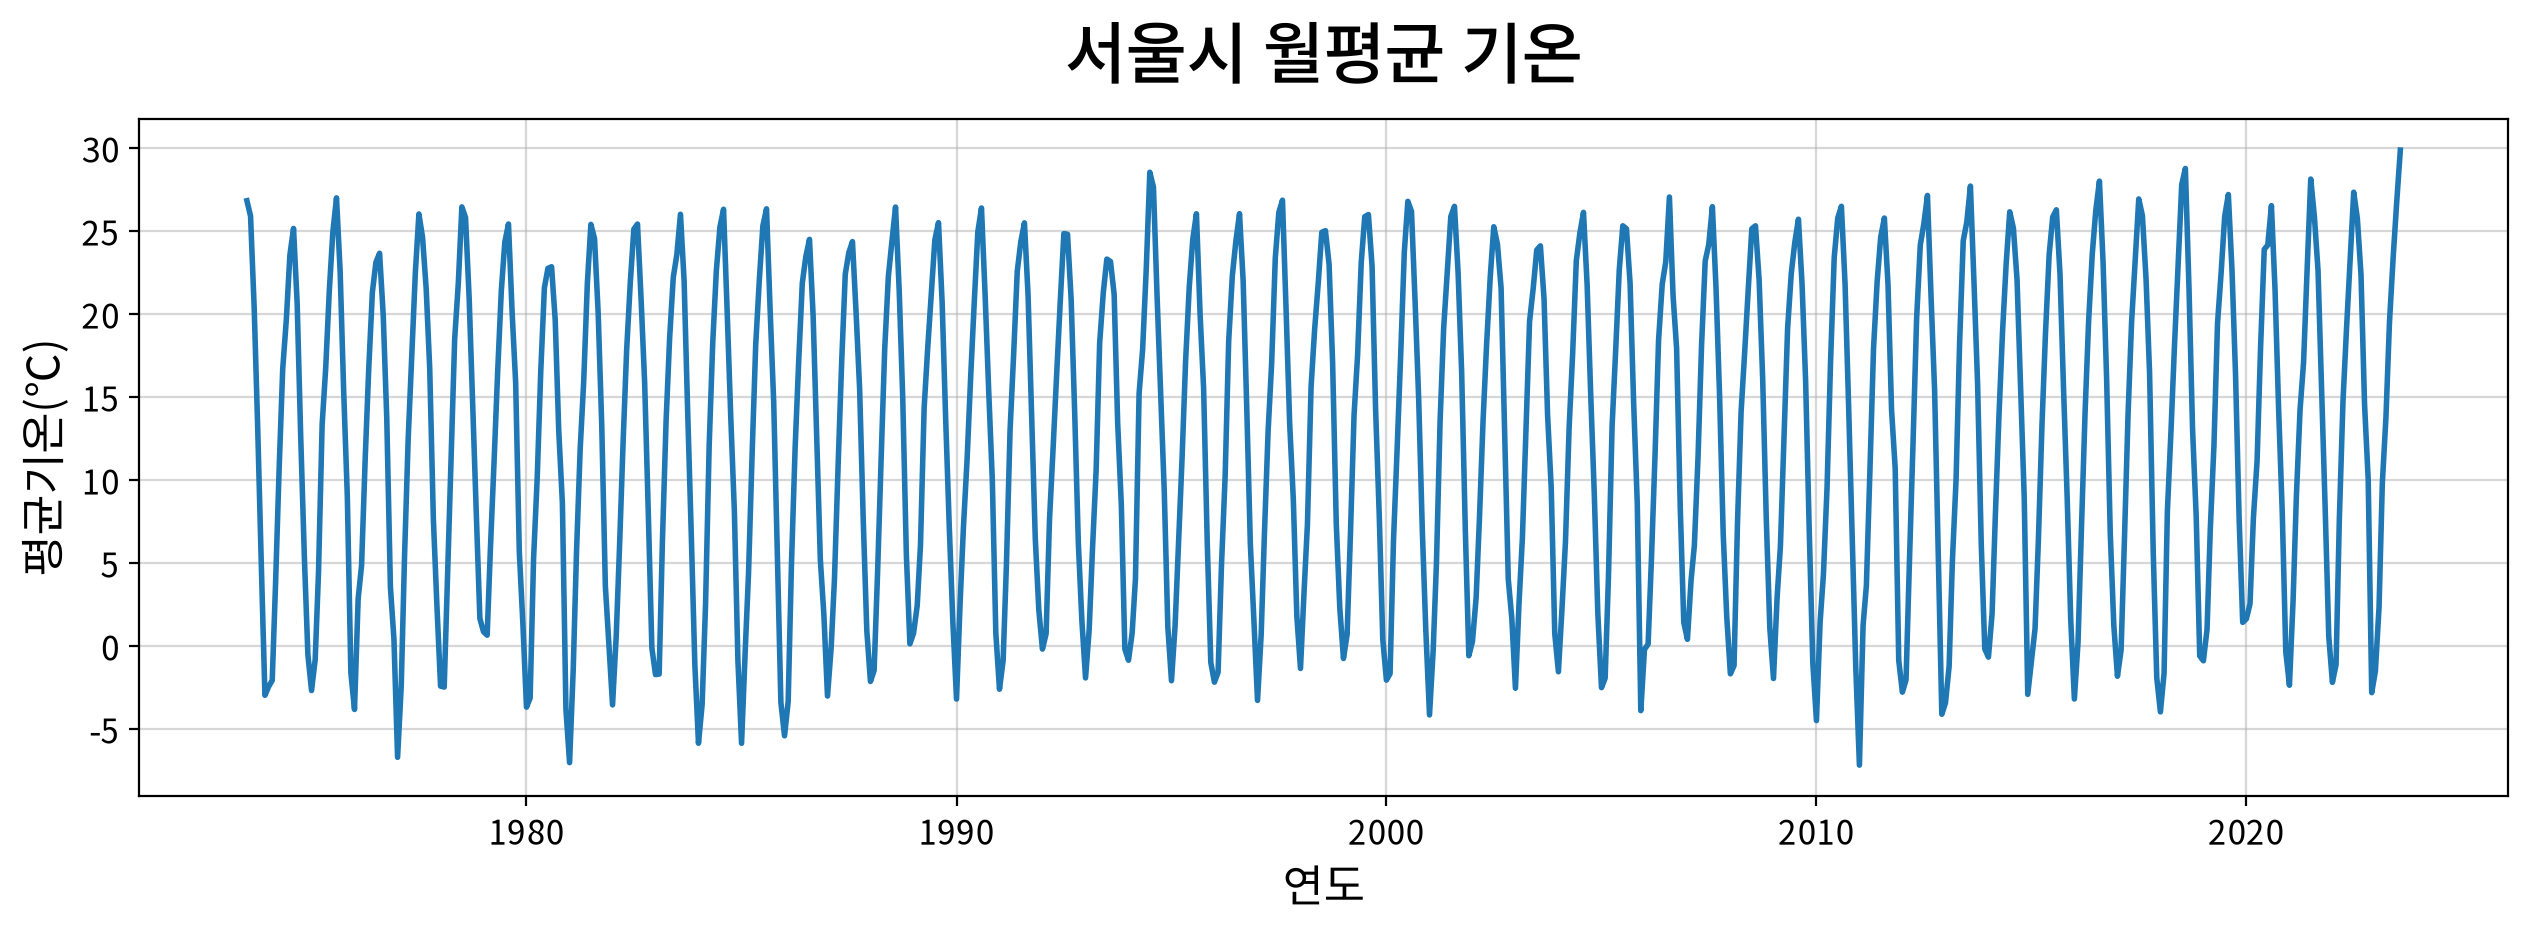

In [12]:
my_plot.lineplot(data=df1, x=df1.index, y="평균기온(℃)", 
                 title="서울시 월평균 기온", 
                 xlabel="연도", ylabel="평균기온(℃)", 
                 width=1280, height=480)

In [13]:
size = len(df1)// 3 # 데이터를 3개 구간으로 나눔
parts = [] 

for i in range(3): #구간 수 만큼 반복
    # 구간의 시작 위치 (0*12, 1*12, 2*12) ~ 끝 위치(1*12, 2*12, 3*12)사이를 자름 
    part = df1['평균기온(℃)'].iloc[i * size : (i +1)*size]   

    # 구간 내 평균과 표준편차를 계산하여 리스트에 추가 
    parts.append({
        "구간": f"구간 {i+1}", 
        "시작": part.index[0].strftime("%Y-%m"),
        "종료": part.index[-1].strftime("%Y-%m"),
        "평균": round(part.mean(), 2), 
        "표준편차": round(part.std(), 2),
    })  

DataFrame(parts)

,구간,시작,종료,평균,표준편차
0,구간 1,1973-07,1990-02,11.850,10.060
1,구간 2,1990-03,2006-10,12.970,9.590
2,구간 3,2006-11,2023-06,12.860,10.080


조건1 충족 - 평균 거의 변하지 않음 - 추세 없음 

조건2 충족 - 표준편차 거의 일정 - 변동폭 일정 

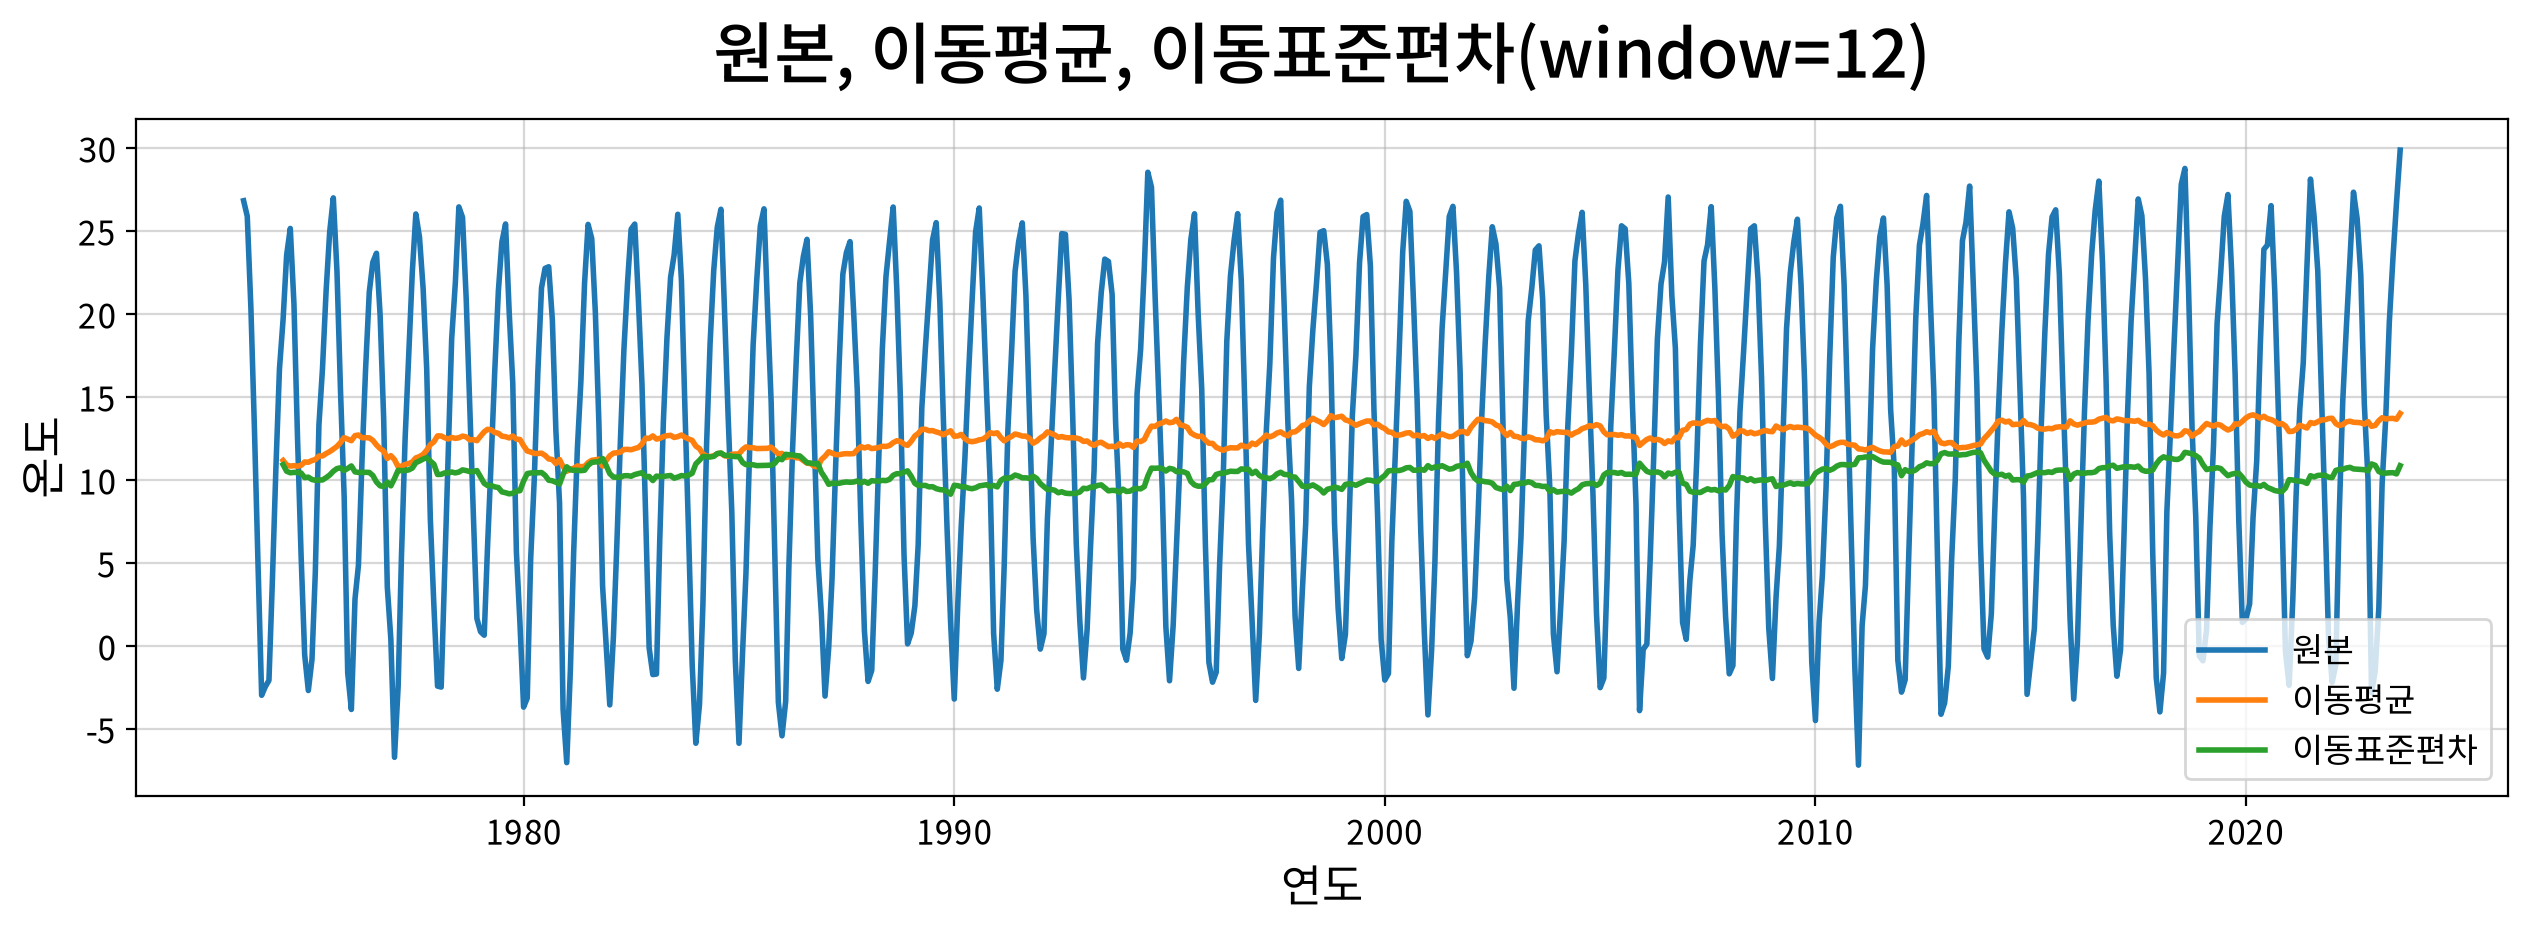

In [14]:
window = 12 # 월간 데이터이므로 1년=12개월

roll_mean = df1['평균기온(℃)'].rolling(window).mean()
roll_std = df1['평균기온(℃)'].rolling(window).std()

fig, ax = my_plot.init(width=1280, height=480,
                       title=f"원본, 이동평균, 이동표준편차(window={window})",
                       xlabel="연도", ylabel="온도")

my_plot.lineplot(x=df1.index, y=df1['평균기온(℃)'], label="원본", ax=ax)
my_plot.lineplot(x=roll_mean.index, y=roll_mean, label="이동평균", ax=ax)
my_plot.lineplot(x=roll_std.index, y=roll_std, label="이동표준편차", ax=ax)

ax.legend()
my_plot.show()

이동평균이 10.5 ~ 14.0 사이의 좁은 폭에서 거의 수평으로 움직임.
-> 평균이 일정하다 

이동표준편차도 9.1 ~ 11.7 사이에서 거의 수평. 
-> 분산이 일정하다 

둘다 수평선에 가깝다. \
원본 상태에서 이미 정상 시계열의 모습에 가깝다. 

# ADF 검정 

그래프는 주관적이므로 통계적 가설검정으로 판정한다. \
본문에서 만든 함수를 그대로 쓴다. 

In [15]:
def adf_test(data, name):
    x = Series(data).dropna() # 결측치 제거 
    stat, pvalue, lag, _, crit, _ = adfuller(x) # ADF 검정 수행 

    return {
        "대상": name, 
        "관측치 수": len(x), 
        "검정통계량(ADF)": round(stat, 3), #검정통계량
        "p-value": round(pvalue, 3), # p-value
        "사용 시차": lag, # 사용된 시차 수 
        "1% 기각값": round(crit["1%"], 3), 
        "5% 기각값": round(crit["5%"], 3), 
        "10% 기각값": round(crit["10%"], 3),
        "판정": "정상" if pvalue < 0.05 else "비정상", 
    }

In [16]:
r_origin = adf_test(df1["평균기온(℃)"], "원본")

Series(r_origin)

대상               원본
관측치 수           602
검정통계량(ADF)   -3.877
p-value       0.002
사용 시차            14
1% 기각값       -3.442
5% 기각값       -2.866
10% 기각값      -2.569
판정               정상
dtype: object

#### 💡 인사이트 - 이 문제에서 가장 조심해야 할 지점 ★

**원본이 이미 "정상" 판정을 받았다.** (ADF = -3.877, p = 0.002)

항공 데이터의 원본은 ADF = +0.815, p = 0.992 로 명백한 비정상이었는데, 여기서는 정반대다.

| 항목 | 항공 승객 수 (원본) | 서울 기온 (원본) |
|---|---|---|
| 검정통계량 | +0.815 | **-3.877** |
| p-value | 0.992 | **0.002** |
| 판정 | 비정상 | **정상** |

> ★ **그런데 그래프에는 계절성이 그렇게 뚜렷한데 왜 정상이라고 나오는가?**
>
> **ADF 검정은 단위근(추세)만 본다.** 매년 똑같이 반복되는 계절성은 단위근이 아니다.
> 여름에 올라간 만큼 겨울에 내려와서 **평균으로 되돌아오기 때문**이다.
> 즉 ADF 입장에서는 "정처 없이 떠돌지 않으므로 정상"이 맞다.
>
> **그래서 p-value만 보고 "전처리 끝"이라고 판단하면 안 된다.**
> 계절성이 남아 있으면 모형이 그 반복 패턴을 매번 다시 학습해야 하므로,
> **계절성은 ADF와 별개로 제거 대상**이다.

## # 처방 - 변환 

변환은 분산 문제(조건2)를 푸는 도구이다. \
이 데이터에 필요한지 먼저 확인한다. 

In [17]:
# 연도별 표준편차로 변동폭이 커지는지 확인 
std_year = df1['평균기온(℃)'].groupby(df1.index.year).std()

print(f"연도별 표준편차 - 최소: {std_year.min():.3f}, 최대: {std_year.max():.3f}")
print(f"최대/최소 비율: {std_year.max() / std_year.min():.2f}배")

# 로그 변환이 가능한지 확인 (0 이하의 값이 있으면 불가 )
print(f"\n0℃ 이하인 달: {(df1['평균기온(℃)'] <= 0).sum()}개월/ 전체{len(df1)}개월")
print(f"최저 기온: {df1['평균기온(℃)'].min():.2f}℃")

연도별 표준편차 - 최소: 9.137, 최대: 11.985
최대/최소 비율: 1.31배

0℃ 이하인 달: 90개월/ 전체602개월
최저 기온: -7.18℃


#### 💡 인사이트

**변환은 쓰지 않는다.** 두 가지 이유가 모두 성립한다.

| 이유 | 근거 |
|---|---|
| ① **필요가 없다** | 연도별 표준편차 최대/최소 비율이 **1.31배**다. 항공 데이터는 **5.67배**였다 |
| ② **쓸 수도 없다** | 영하인 달이 **90개월** 있고 최저 -7.18℃다. **로그는 0 이하에서 정의되지 않는다** |

> ★ 기온처럼 **0을 지나는 데이터(영상·영하)** 에는 로그변환을 적용할 수 없다.
> 로그변환은 "몇 % 성장" 같은 **비율로 커지는 양수 데이터**를 위한 도구다.
> 승객 수·매출·인구는 되지만 기온·수익률·위도는 안 된다.

> 그래서 이 문제의 답에는 **변환이 들어가지 않는다.**

## # 처방2 - 차분 Differencing

1. 일반차분이 필요한가 - 과대차분 확인 
 
차분을 반복하며 표준편차가 어떻게 변하는지 관찰한다. 

In [18]:
over_diff = [] #차분 횟수별 ADF 검정 결과를 담을 리스트 
tmp = df1["평균기온(℃)"].copy() # 원본 데이터를 복사하여 차분 수행 

for i in range(4): #0차 ~ 3차 차분까지 반복
    r = adf_test(tmp,f"{i}차 차분" if i >0 else "원본") # ADF 검정 수행 
    r["표준편차"] = round(tmp.std(),2) #표준편차 계산 
    over_diff.append(r) #결과를 리스트에 추가 
    tmp = tmp.diff().dropna() # 다음 차분을 위해 1차 차분 수행 후 결측치 제거 

DataFrame(over_diff)[["대상", "관측치 수", "검정통계량(ADF)", "p-value","판정", "표준편차"]]

,대상,관측치 수,검정통계량(ADF),p-value,판정,표준편차
0,원본,602,-3.877,0.002,정상,9.930
1,1차 차분,601,-10.529,0.000,정상,5.410
2,2차 차분,600,-13.340,0.000,정상,3.980
3,3차 차분,599,-18.990,0.000,정상,5.400


#### 💡 인사이트

| 차수 | p-value | 표준편차 | 판단 |
|---|---|---|---|
| 원본 | 0.002 | **9.93** | 이미 정상 |
| 1차 차분 | 0.000 | 5.41 | |
| 2차 차분 | 0.000 | 3.98 | |
| 3차 차분 | 0.000 | 5.40 ↑ | 분산 증가 |

- 모든 차수가 "정상"이다. **p-value로는 아무것도 고를 수 없다.**
- 표준편차만 보면 2차 차분이 최소지만, **이 감소는 추세를 없앤 것이 아니라 계절 진동을 깎아낸 결과**다.
- 애초에 **#03에서 추세가 없다는 것을 확인**했다. 없는 추세를 지우려고 차분할 이유가 없다.

> ★ **차분은 "추세가 있을 때" 쓰는 도구다.** p-value나 표준편차가 좋아 보인다고 쓰는 것이 아니다.
> 남은 문제가 무엇인지 먼저 진단하고, 그 문제에 맞는 처방을 골라야 한다.
> 이 데이터에 남은 문제는 추세가 아니라 **계절성**이다.

### 2. 계절차분 (Seasonal Differencing)

일반 차분이 **직전 값**과 비교했다면, 계절차분은 **작년 같은 달**과 비교한다.

$$\Delta_{12} \, y_t = y_t - y_{t-12}$$

- 월간 데이터이고 매년 같은 모양이 반복되므로 계절 주기는 $s = 12$ 다.
- `diff(12)`로 수행하며 앞의 12개 행이 결측치가 된다.

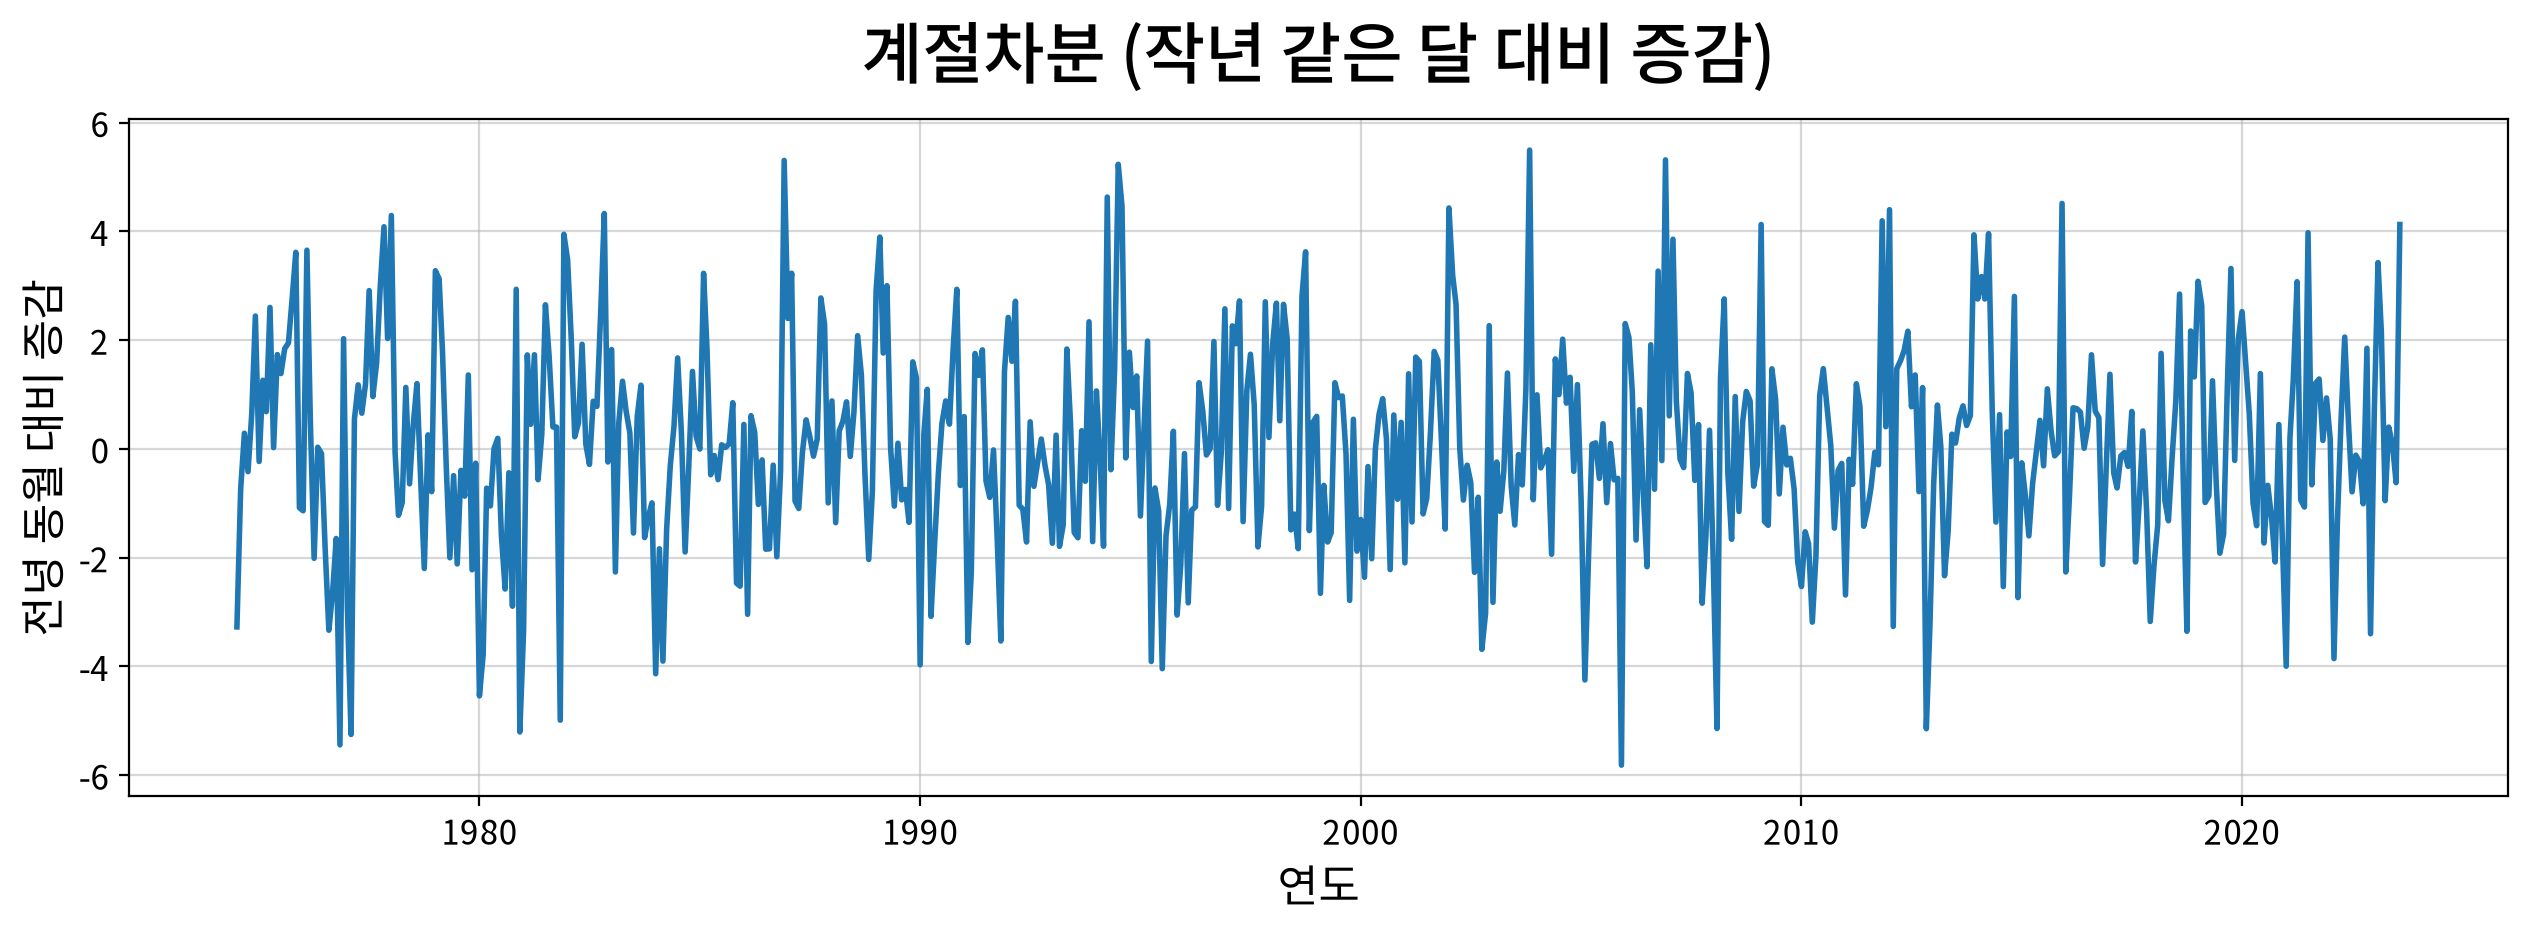

대상            계절차분(12)
관측치 수              590
검정통계량(ADF)      -8.829
p-value          0.000
사용 시차               12
1% 기각값          -3.442
5% 기각값          -2.867
10% 기각값         -2.569
판정                  정상
dtype: object

In [19]:
df3 = df1["평균기온(℃)"].diff(12).dropna()

my_plot.lineplot(x=df3.index, y=df3, title="계절차분 (작년 같은 달 대비 증감)", 
                 xlabel="연도", ylabel="전녕 동월 대비 증감", 
                 width=1280, height=480)

r_ds = adf_test(df3, "계절차분(12)") #ADF 검정 수행 
Series(r_ds)

#### 💡 인사이트

- 그래프에서 **매년 반복되던 봉우리와 골이 완전히 사라졌다.** 0을 중심으로 무작위로 흩어진다.
- ADF = **-8.829**, p = 0.000 으로 원본(-3.877)보다 **훨씬 강한 정상성**을 얻었다.
- 표준편차가 **9.93 → 1.88 로 5분의 1 이하**가 되었다.

> ★ 표준편차가 이렇게 줄었다는 것은 **원본 변동의 대부분이 계절성이었다**는 뜻이다.
> 서울의 기온은 "올해가 작년보다 더운가"보다 **"지금이 여름인가 겨울인가"** 로 거의 결정된다.
> 그 계절 성분을 걷어내자 ±2℃ 남짓의 잔변동만 남았다.

## # 전처리 조합 비교 - 무엇을 쓸 것인가 

가능한 조합을 한꺼번에 비교한다. \
로그변환은 영하 값 때문에 적용할 수 없으므로 조합에서 제외한다.

In [20]:
s = df1["평균기온(℃)"]
ls = np.log(s)

combos = {
    "1. 원본":s,
    "2. 1차 차분": s.diff(), 
    "3. 2차 차분": s.diff().diff(),
    "4. 계절차분(12)": s.diff(12),
    "5. 1차 차분 + 계절차분(12)": s.diff().diff(12),
}

c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [21]:
report = [] # ADF 검정 결과를 담을 리스트 

for name , x in combos.items() : # combos 딕셔너리의 Key, value를 순회 
    r = adf_test(x, name) #ADF 검정 수행 
    r["표준편차"] = round(x.dropna().std(),3) #표준편차 계산 
    report.append(r) #결과를 리스트에 추가 

# ADF 검정 결과를 데이터 프레임으로 변환하여 출력 
DataFrame(report)[["대상", "관측치 수","검정통계량(ADF)", "p-value", "5% 기각값", "표준편차", "판정"]]

,대상,관측치 수,검정통계량(ADF),p-value,5% 기각값,표준편차,판정
0,1. 원본,602,-3.877,0.002,-2.866,9.932,정상
1,2. 1차 차분,601,-10.529,0.000,-2.866,5.407,정상
2,3. 2차 차분,600,-13.340,0.000,-2.867,3.982,정상
3,4. 계절차분(12),590,-8.829,0.000,-2.867,1.881,정상
4,5. 1차 차분 + 계절차분(12),589,-10.251,0.000,-2.867,2.371,정상


#### 💡 인사이트

| 조합 | p-value | 표준편차 | 평가 |
|---|---|---|---|
| ① 원본 | 0.002 | 9.932 | 정상 판정이지만 **계절성이 그대로 남아 있다** |
| ② 1차 차분 | 0.000 | 5.407 | 없는 추세를 지웠다 |
| ③ 2차 차분 | 0.000 | 3.982 | 과대차분 |
| **④ 계절차분(12)** | **0.000** | **1.881 ← 최소** | **계절성만 정확히 제거 — 최선** |
| ⑤ 1차 차분 + 계절차분(12) | 0.000 | 2.371 ↑ | 불필요한 차분을 더해 **분산이 다시 커졌다** |

> ★ **판정 기준은 p-value가 아니라 표준편차다.**
> 다섯 조합 모두 p < 0.05 로 "정상"이므로 p-value로는 우열을 가릴 수 없다.
> **표준편차가 최소가 되는 ④를 고른다.**
>
> ⑤를 보면 규칙이 왜 필요한지 분명해진다. 계절차분에 1차 차분을 **더했더니**
> 표준편차가 1.881 → **2.371로 오히려 커졌다.** 없던 노이즈를 만들어낸 것이다.
> 이것이 본문에서 배운 **과대차분(over-differencing)** 이다.

> ★ **결론: ④ 계절차분(12) 한 번만 적용한다.**

## #08. 정답

### 문제의 답

| 항목 | 값 | 근거 |
|---|---|---|
| 변환 | **없음** | 연도별 표준편차 비율 1.31배로 분산이 일정하고, 영하 값(90개월)이 있어 로그 적용 불가 |
| 일반차분 횟수 | **0회** | 구간별 평균 11.85 → 12.97 → 12.86, 이동평균 수평 → **추세가 없다** |
| 계절차분 횟수 | **1회** | 계절성이 뚜렷하고, 계절차분 후 표준편차가 9.93 → 1.88 로 최소 |
| 계절 주기 | **12개월** | 월간 데이터이며 매년 같은 모양이 반복 |

$$\boxed{\;d = 0, \quad D = 1, \quad s = 12\;}$$

**총 적용된 변환은 1회 — 계절차분(12) 한 번뿐이다.**

### 항공 승객 수 데이터와 비교

| 항목 | 항공 승객 수 | 서울 월평균 기온 |
|---|---|---|
| 추세 | 뚜렷한 우상향 | 거의 없음 |
| 계절성 | 있음 (12개월) | 있음 (12개월) — **매우 강함** |
| 변동폭 | 수준에 비례해 증가 | 일정 |
| 원본 ADF 판정 | 비정상 (p=0.992) | **정상 (p=0.002)** |
| 변환 | 로그변환 | **없음** (영하 값으로 불가) |
| **최종 결론** | $d=1,\ D=1,\ s=12$ | $d=0,\ D=1,\ s=12$ |

### 이 문제에서 반드시 짚어야 할 것

| 원칙 | 이 데이터에서의 확인 |
|---|---|
| 🔑 ADF는 추세만 본다 | 계절성이 뚜렷해도 **정상 판정이 나올 수 있다.** p-value만 믿으면 계절성을 놓친다 |
| 🔑 처방은 문제별로 다르다 | 추세가 없으면 **차분하지 않는다.** 없는 문제를 고치면 데이터만 상한다 |
| 🔑 로그변환은 양수 전용 | 0 이하 값이 하나라도 있으면 **적용 자체가 불가능**하다 |
| 🔑 과대차분을 피하라 | ⑤에서 표준편차가 1.881 → 2.371로 **커지는 것**을 직접 확인했다 |
| 🔑 p-value는 목표가 아니다 | 모든 조합이 p < 0.05였다. 선택 기준은 **표준편차 최소**였다 |